# FIRST VERSUS OTHER H-H INTERACTION

In [110]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sys
import matplotlib.patches as mpatches
import matplotlib as mpl

# ---- Adobe-friendly fonts (must be set BEFORE plotting) ----
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42



df1 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/group-housed/fed-fed/head_head_contacts_kinematics_over_time_nocontacts_ref-window10.csv')
df1['Condition'] = 'GH Fed-Fed'

df2 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/group-housed/fed-starved/head_head_contacts_kinematics_over_time_nocontacts_ref-window10.csv')
df2['Condition'] = 'GH Fed-Starved'

df3 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/group-housed/starved-starved/head_head_contacts_kinematics_over_time_nocontacts_ref-window10.csv')
df3['Condition'] = 'GH Starved-Starved'



df4 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/socially-isolated/fed-fed/head_head_contacts_kinematics_over_time_nocontacts_ref-window10.csv')
df4['Condition'] = 'SI Fed-Fed'

df5 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/socially-isolated/fed-starved/head_head_contacts_kinematics_over_time_nocontacts_ref-window10.csv')
df5['Condition'] = 'SI Fed-Starved'

df6 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/socially-isolated/starved-starved/head_head_contacts_kinematics_over_time_nocontacts_ref-window10.csv')
df6['Condition'] = 'SI Starved-Starved'

df = pd.concat([df1, df2, df3, df4, df5, df6], ignore_index=True)



df['interaction_group'] = np.select(
    [
        (df['interaction_number'] == 1) & (df['interaction_frame'] < 1200),
        (df['interaction_number'] == 1) & (df['interaction_frame'] >= 1200),
    ],
    [
        'first',
        'not_viable_first',
    ],
    default='other'
)
df = df[df['interaction_group'] != 'not_viable_first'].copy()


# #### NEW
# df = df[
#     (df['interaction_number'] == 1) &
#     (df['interaction_frame'] < 1200)
# ].copy()

# df['interaction_group'] = np.where(df['interaction_number'] == 1, 'first', 'other')

si = df[df['Condition'].str.contains('SI')].copy()
gh = df[df['Condition'].str.contains('GH')].copy()

metrics = ['speed_head', 'speed_body', 'speed_tail', 'heading_angle', 'heading_angle_change', 'approach_angle', 'approach_angle_head', 'cum_distance_start', 'cum_distance_0', 'distance_from_0', 'directional_alignment_cosine', 'track0_projection_onto_track1', 'head_distance']

file_larva_timecourse = (
    df.groupby(['Condition', 'file', 'track_id', 'interaction_group', 'rel_frame'])[metrics]
      .mean()
      .reset_index()
)

si_file_larva_timecourse = file_larva_timecourse[file_larva_timecourse['Condition'].str.contains('SI')].copy()
gh_file_larva_timecourse = file_larva_timecourse[file_larva_timecourse['Condition'].str.contains('GH')].copy()





######### TOTAL NUMBER OF HEAD-HEAD INTERACTION BOUTS

/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_43987/1483801630.py:10: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(data=interactions_per_file, x='Condition', y='number_of_interactions', ci='sd')


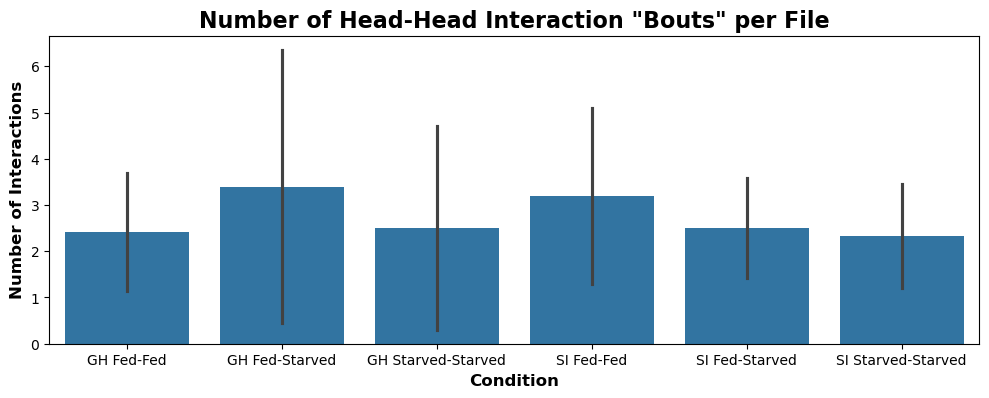

In [111]:
interactions_per_file = (
    df.groupby(['Condition', 'file'])['interaction_number']
      .max()
      .reset_index(name='number_of_interactions')
)


plt.figure(figsize = (12, 4))

sns.barplot(data=interactions_per_file, x='Condition', y='number_of_interactions', ci='sd')

plt.xlabel('Condition', fontsize=12, fontweight='bold')
plt.ylabel('Number of Interactions', fontsize=12, fontweight='bold')
plt.title('Number of Head-Head Interaction "Bouts" per File', fontsize=16, fontweight='bold')
plt.show()

####### TAIL SPEED OVER TIME - FIRST/OTHER INTERACTION

KeyboardInterrupt: 

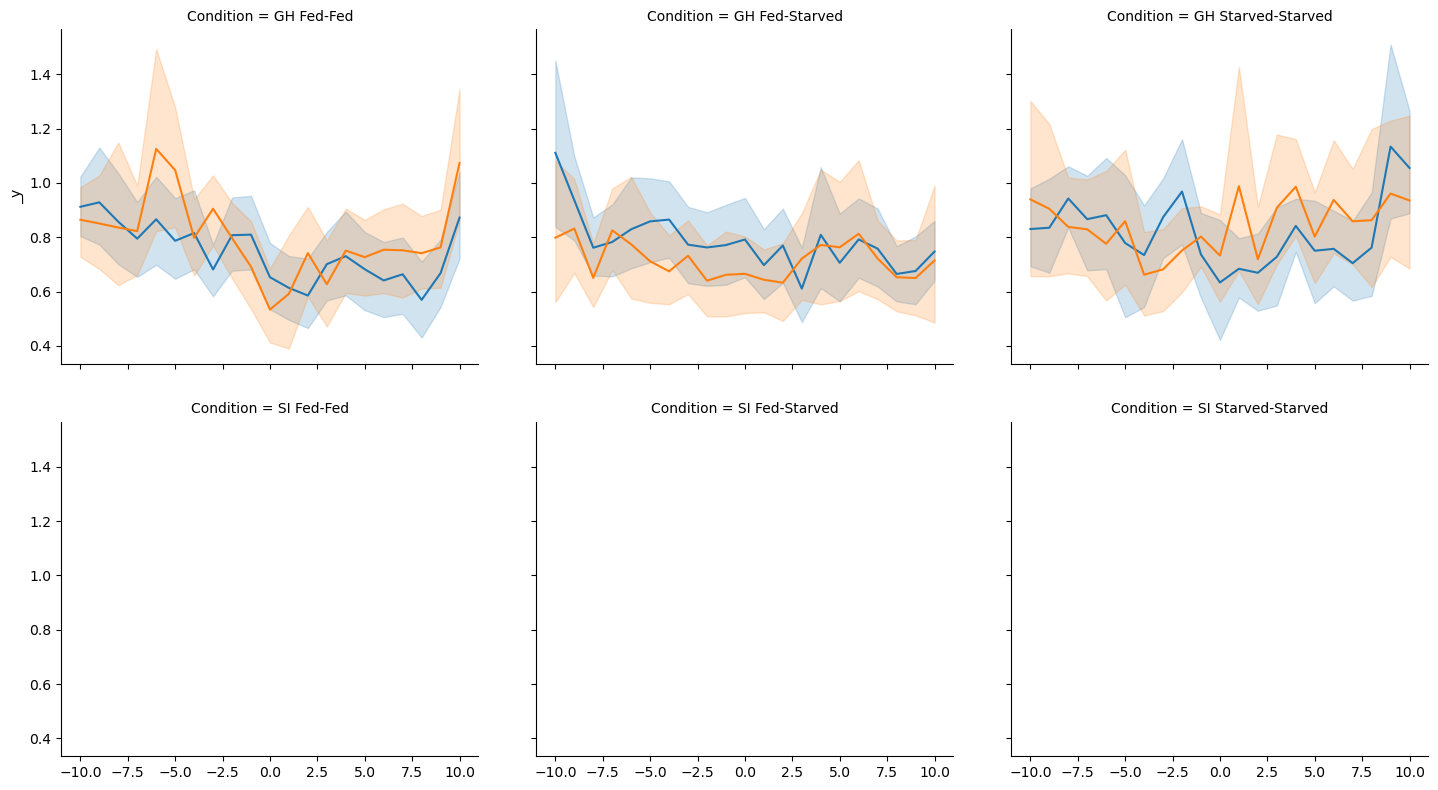

In [112]:
g = sns.relplot(
    data=file_larva_timecourse,
    x='rel_frame',
    y='speed_tail',
    hue='interaction_group',
    col='Condition',
    col_wrap=3,
    kind='line',
    errorbar=('ci', 95),
    height=4,
    aspect=1.2
)

g.set_axis_labels('Relative frame', 'Tail speed')
g.set_titles('{col_name}')

for ax in g.axes.flat:
    ax.axvline(0, color='black', linestyle='--', linewidth=1)
    ax.set_title(ax.get_title(), fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

####### HEAD SPEED OVER TIME - FIRST/OTHER INTERACTION

/Users/cochral/miniconda3/envs/maggots/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_43987/588851750.py:21: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


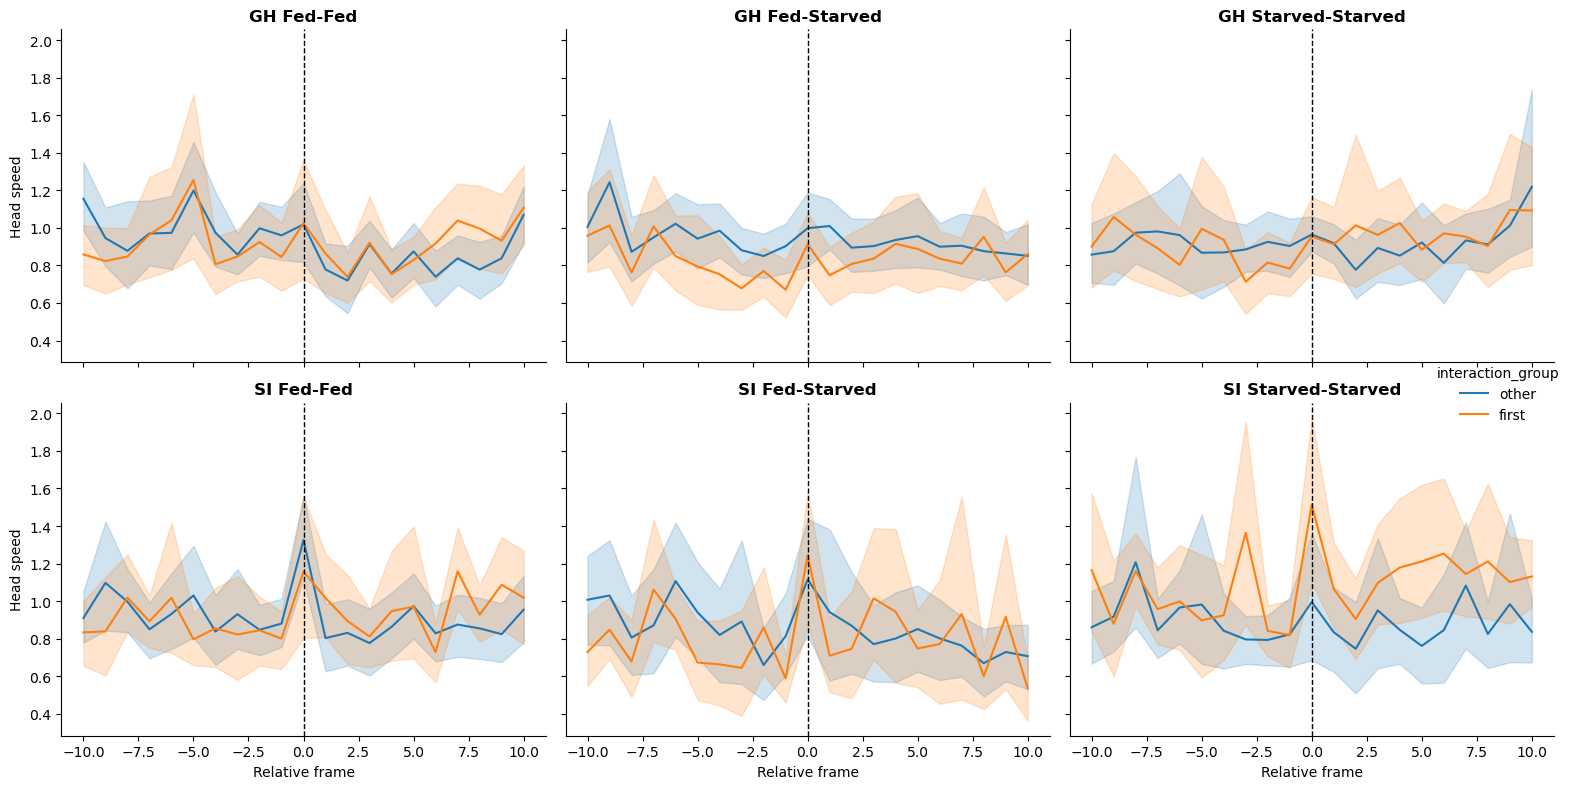

In [ ]:
g = sns.relplot(
    data=file_larva_timecourse,
    x='rel_frame',
    y='speed_head',
    hue='interaction_group',
    col='Condition',
    col_wrap=3,
    kind='line',
    errorbar=('ci', 95),
    height=4,
    aspect=1.2
)

g.set_axis_labels('Relative frame', 'Head speed')
g.set_titles('{col_name}')

for ax in g.axes.flat:
    ax.axvline(0, color='black', linestyle='--', linewidth=1)
    ax.set_title(ax.get_title(), fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

###### HEADING ANGLE FIRST OTHER FOR JUST IN GENERAL SI V GH

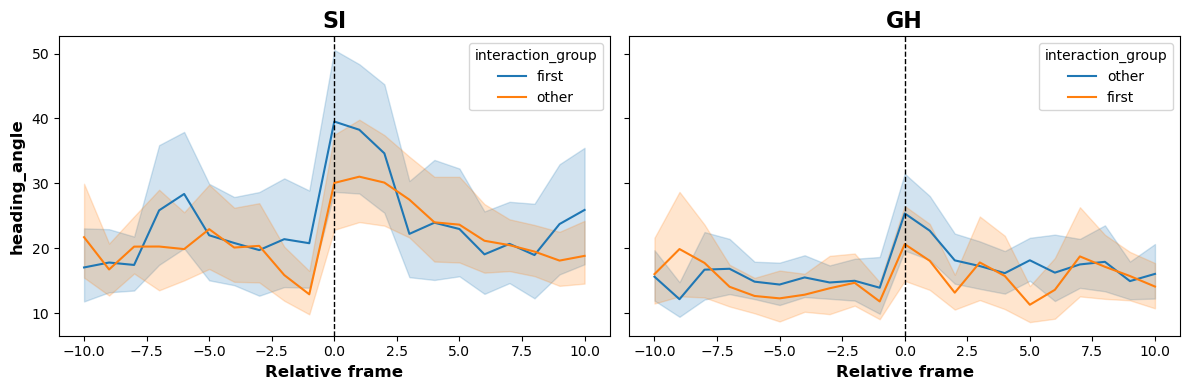

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12,4), sharey=True)

# SI
sns.lineplot(
    data=si_file_larva_timecourse,
    x='rel_frame',
    y='heading_angle',
    hue='interaction_group',
    errorbar=('ci', 95),
    ax=axes[0]
)

axes[0].axvline(0, color='black', linestyle='--', linewidth=1)
axes[0].set_xlabel('Relative frame', fontsize=12, fontweight='bold')
axes[0].set_ylabel('heading_angle', fontsize=12, fontweight='bold')
axes[0].set_title('SI', fontsize=16, fontweight='bold')

# GH
sns.lineplot(
    data=gh_file_larva_timecourse,
    x='rel_frame',
    y='heading_angle',
    hue='interaction_group',
    errorbar=('ci', 95),
    ax=axes[1]
)

axes[1].axvline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_xlabel('Relative frame', fontsize=12, fontweight='bold')
axes[1].set_ylabel('')
axes[1].set_title('GH', fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()

####### HEADING ANGLE  OVER TIME - FIRST/OTHER INTERACTION

/Users/cochral/miniconda3/envs/maggots/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_43987/2381644556.py:21: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


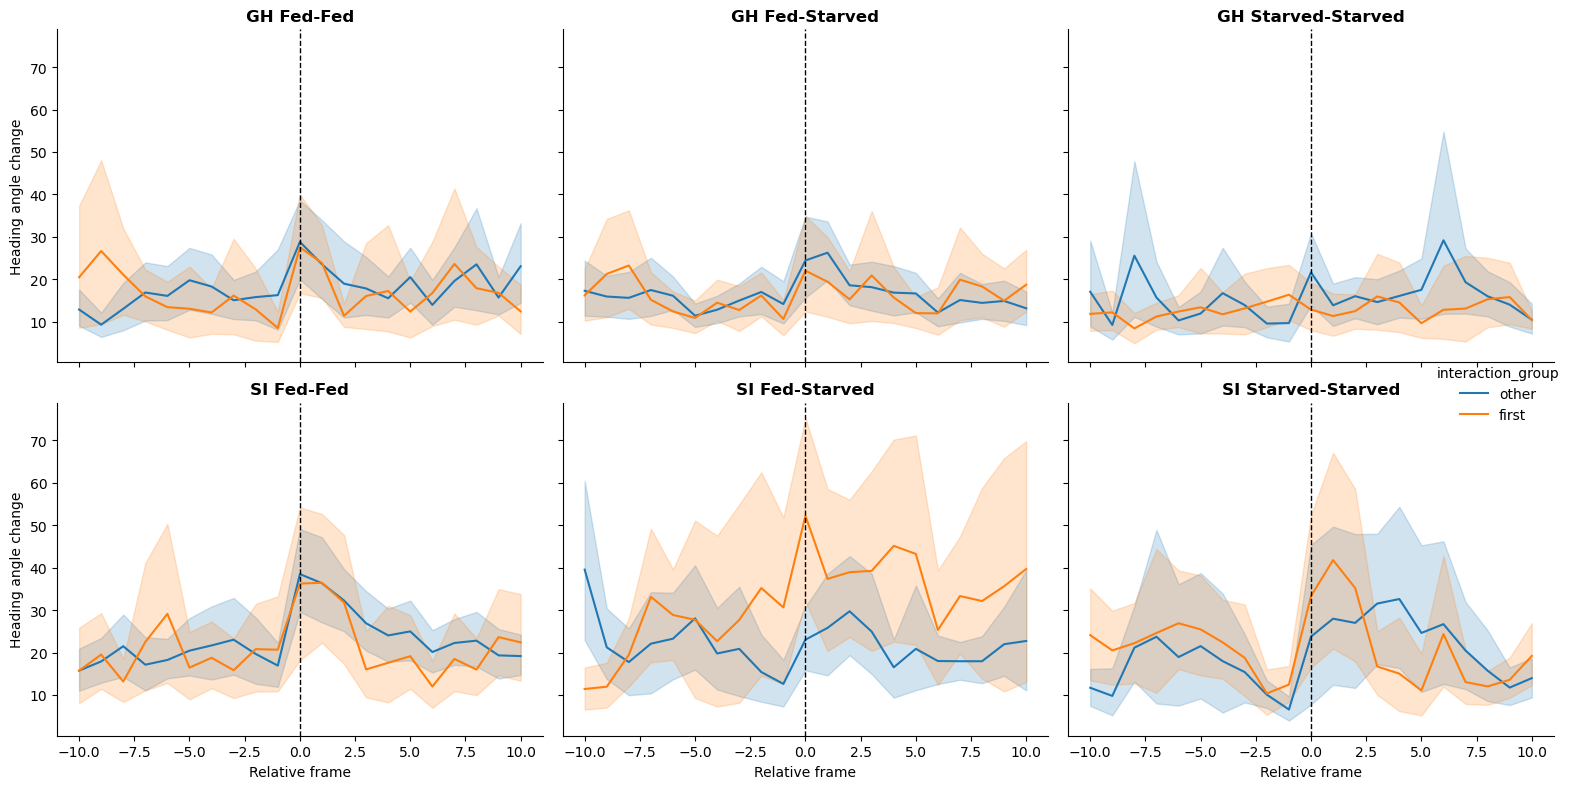

In [ ]:
g = sns.relplot(
    data=file_larva_timecourse,
    x='rel_frame',
    y='heading_angle',
    hue='interaction_group',
    col='Condition',
    col_wrap=3,
    kind='line',
    errorbar=('ci', 95),
    height=4,
    aspect=1.2
)

g.set_axis_labels('Relative frame', 'Heading angle change')
g.set_titles('{col_name}')

for ax in g.axes.flat:
    ax.axvline(0, color='black', linestyle='--', linewidth=1)
    ax.set_title(ax.get_title(), fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

/Users/cochral/miniconda3/envs/maggots/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_43987/4193759352.py:21: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


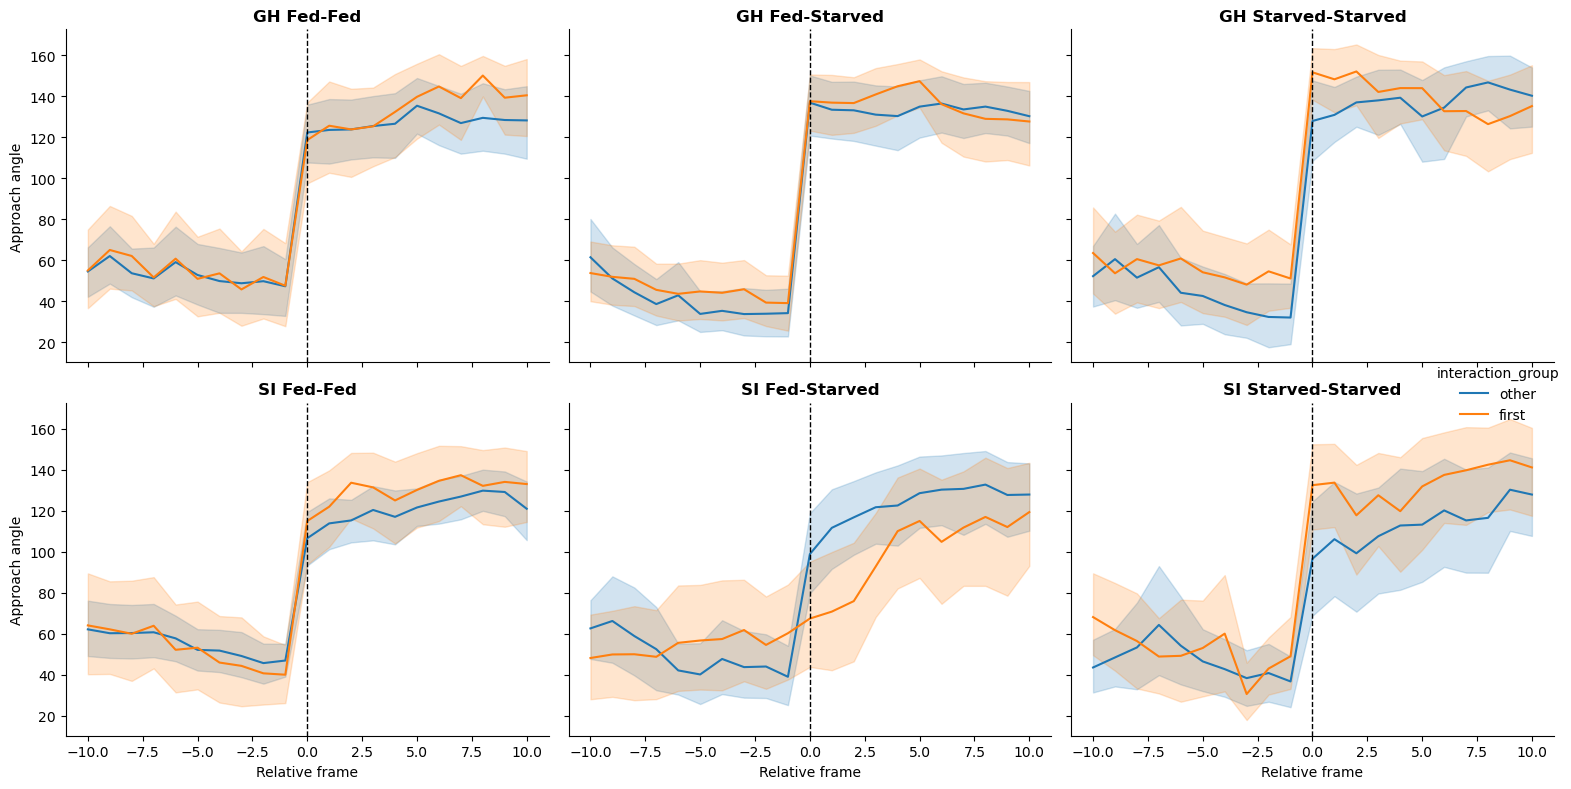

In [ ]:
g = sns.relplot(
    data=file_larva_timecourse,
    x='rel_frame',
    y='approach_angle',
    hue='interaction_group',
    col='Condition',
    col_wrap=3,
    kind='line',
    errorbar=('ci', 95),
    height=4,
    aspect=1.2
)

g.set_axis_labels('Relative frame', 'Approach angle')
g.set_titles('{col_name}')

for ax in g.axes.flat:
    ax.axvline(0, color='black', linestyle='--', linewidth=1)
    ax.set_title(ax.get_title(), fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

####### HEADING ANGLE CHANGE OVER TIME - FIRST/OTHER INTERACTION

/Users/cochral/miniconda3/envs/maggots/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_43987/372607734.py:21: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


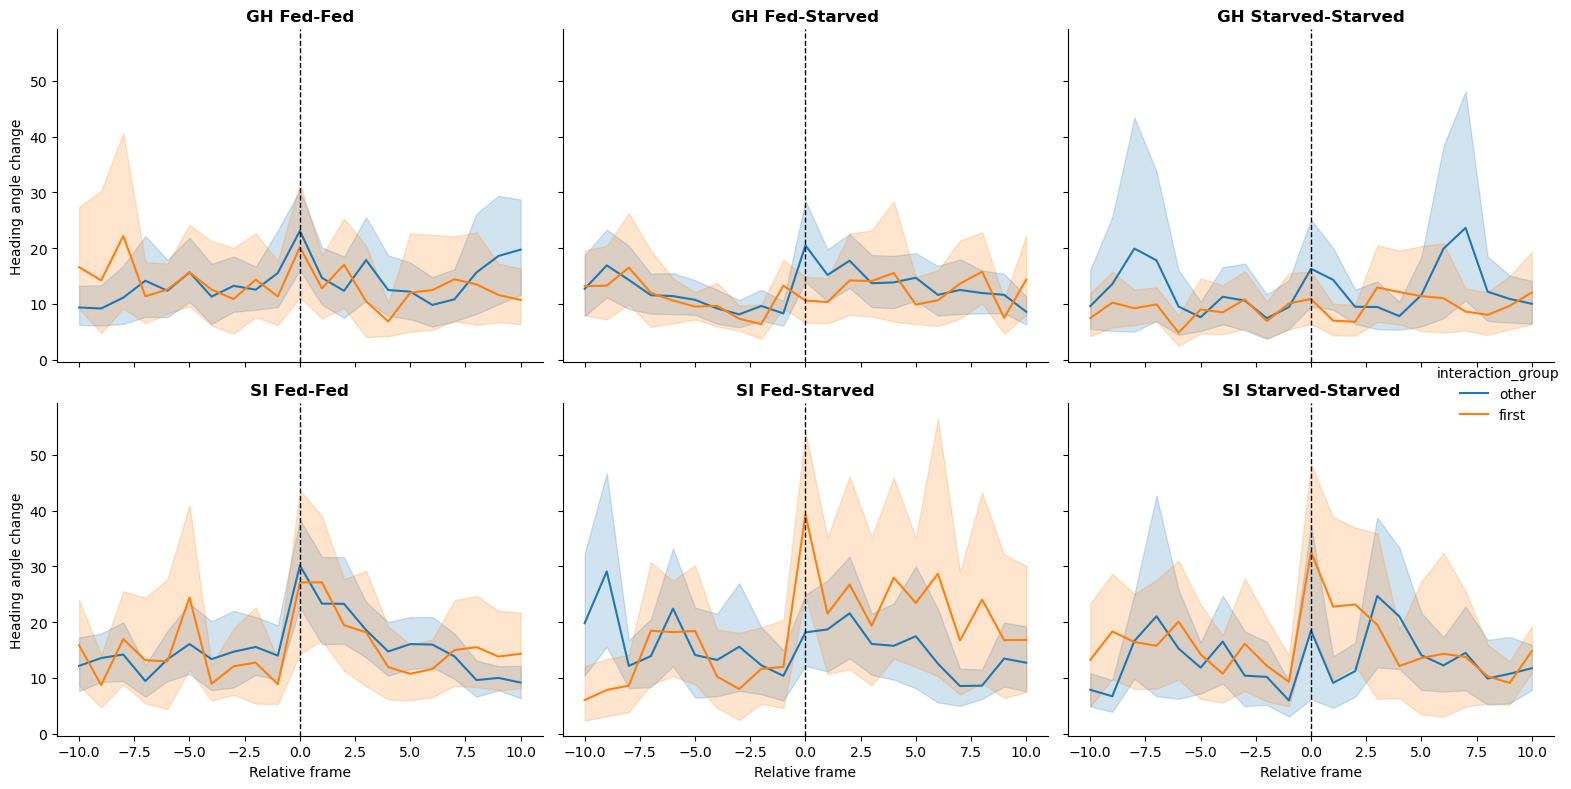

In [ ]:
g = sns.relplot(
    data=file_larva_timecourse,
    x='rel_frame',
    y='heading_angle_change',
    hue='interaction_group',
    col='Condition',
    col_wrap=3,
    kind='line',
    errorbar=('ci', 95),
    height=4,
    aspect=1.2
)

g.set_axis_labels('Relative frame', 'Heading angle change')
g.set_titles('{col_name}')

for ax in g.axes.flat:
    ax.axvline(0, color='black', linestyle='--', linewidth=1)
    ax.set_title(ax.get_title(), fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# FIRST INTERACTION 

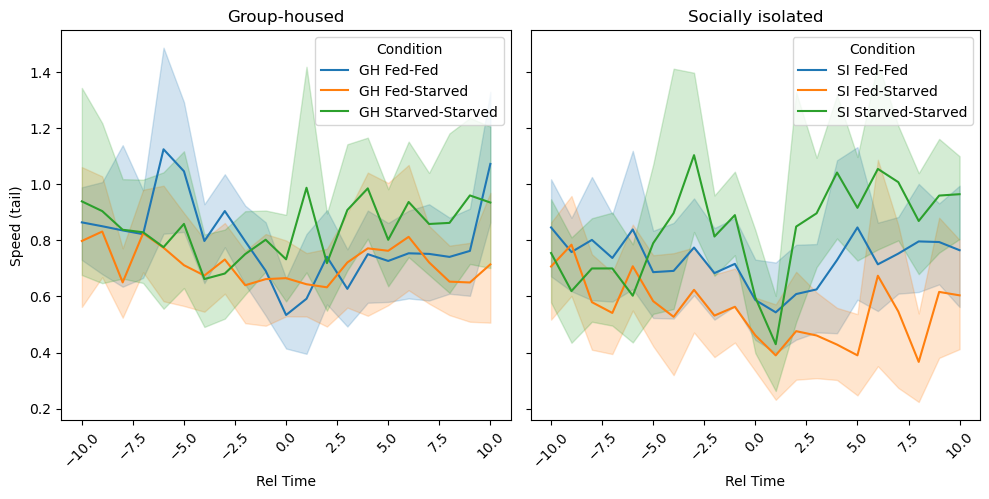

In [ ]:
first_interaction = file_larva_timecourse[file_larva_timecourse['interaction_group'] == 'first']

first_interaction_si = first_interaction[first_interaction['Condition'].str.contains('SI')].copy()
first_interaction_gh = first_interaction[first_interaction['Condition'].str.contains('GH')].copy()

fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=True)

# ---------------- GH ----------------
sns.lineplot(
    data=first_interaction_gh,
    x='rel_frame',
    y='speed_tail',
    hue='Condition',
    ax=axes[0]
)

axes[0].set_title('Group-housed')
axes[0].set_xlabel('Rel Time')
axes[0].set_ylabel('Speed (tail)')
axes[0].tick_params(axis='x', rotation=45)

# ---------------- SI ----------------
sns.lineplot(
    data=first_interaction_si,
    x='rel_frame',
    y='speed_tail',
    hue='Condition',
    ax=axes[1]
)

axes[1].set_title('Socially isolated')
axes[1].set_xlabel('Rel Time')
axes[1].set_ylabel('')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


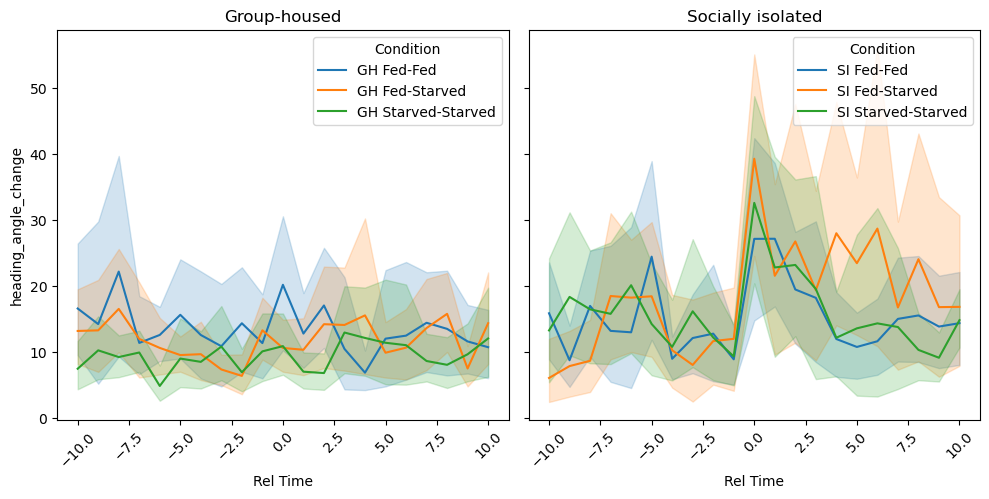

In [ ]:
first_interaction = file_larva_timecourse[file_larva_timecourse['interaction_group'] == 'first']

first_interaction_si = first_interaction[first_interaction['Condition'].str.contains('SI')].copy()
first_interaction_gh = first_interaction[first_interaction['Condition'].str.contains('GH')].copy()

fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=True)

# ---------------- GH ----------------
sns.lineplot(
    data=first_interaction_gh,
    x='rel_frame',
    y='heading_angle_change',
    hue='Condition',
    ax=axes[0]
)

axes[0].set_title('Group-housed')
axes[0].set_xlabel('Rel Time')
axes[0].set_ylabel('heading_angle_change')
axes[0].tick_params(axis='x', rotation=45)

# ---------------- SI ----------------
sns.lineplot(
    data=first_interaction_si,
    x='rel_frame',
    y='heading_angle_change',
    hue='Condition',
    ax=axes[1]
)

axes[1].set_title('Socially isolated')
axes[1].set_xlabel('Rel Time')
axes[1].set_ylabel('')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


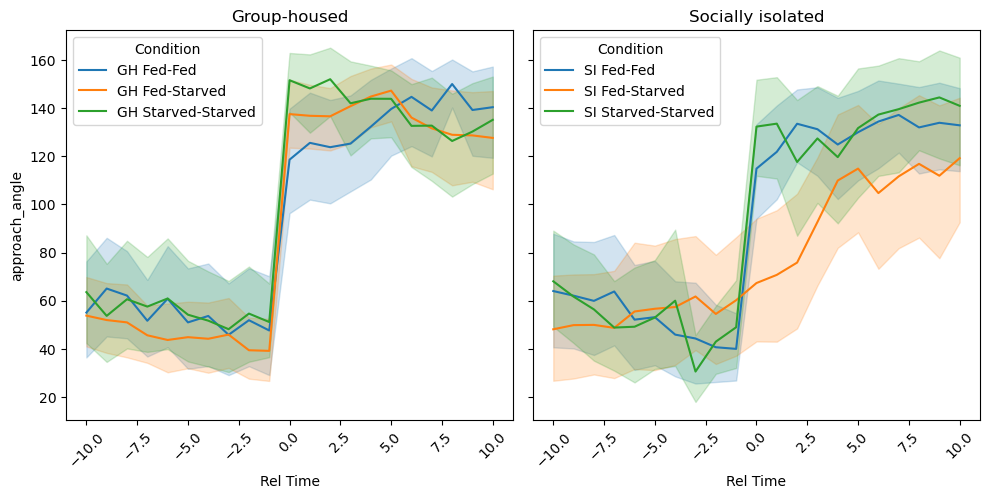

In [ ]:
first_interaction = file_larva_timecourse[file_larva_timecourse['interaction_group'] == 'first']

first_interaction_si = first_interaction[first_interaction['Condition'].str.contains('SI')].copy()
first_interaction_gh = first_interaction[first_interaction['Condition'].str.contains('GH')].copy()

fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=True)

# ---------------- GH ----------------
sns.lineplot(
    data=first_interaction_gh,
    x='rel_frame',
    y='approach_angle',
    hue='Condition',
    ax=axes[0]
)

axes[0].set_title('Group-housed')
axes[0].set_xlabel('Rel Time')

axes[0].set_ylabel('approach_angle')
axes[0].tick_params(axis='x', rotation=45)

# ---------------- SI ----------------
sns.lineplot(
    data=first_interaction_si,
    x='rel_frame',
    y='approach_angle',
    hue='Condition',
    ax=axes[1]
)

axes[1].set_title('Socially isolated')
axes[1].set_xlabel('Rel Time')
axes[1].set_ylabel('')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


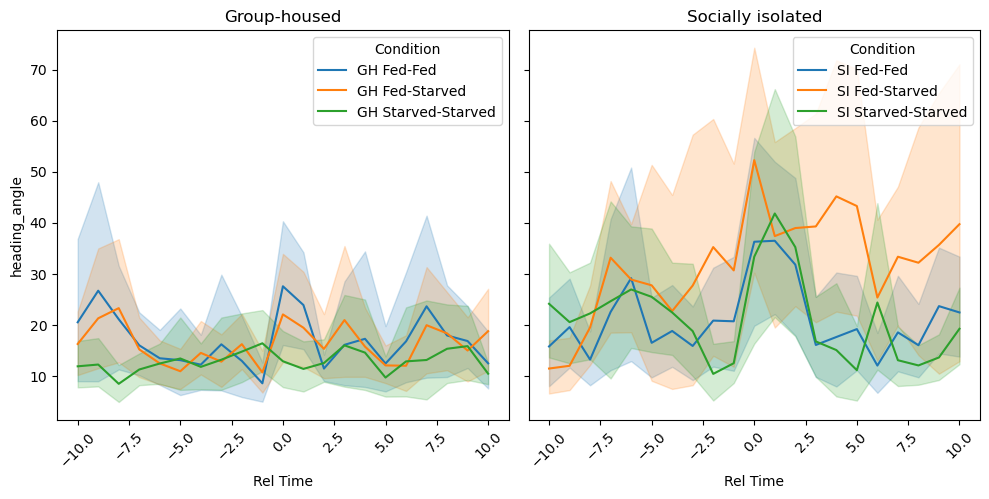

In [ ]:
first_interaction = file_larva_timecourse[file_larva_timecourse['interaction_group'] == 'first']

first_interaction_si = first_interaction[first_interaction['Condition'].str.contains('SI')].copy()
first_interaction_gh = first_interaction[first_interaction['Condition'].str.contains('GH')].copy()

fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=True)

# ---------------- GH ----------------
sns.lineplot(
    data=first_interaction_gh,
    x='rel_frame',
    y='heading_angle',
    hue='Condition',
    ax=axes[0]
)

axes[0].set_title('Group-housed')
axes[0].set_xlabel('Rel Time')

axes[0].set_ylabel('heading_angle')
axes[0].tick_params(axis='x', rotation=45)

# ---------------- SI ----------------
sns.lineplot(
    data=first_interaction_si,
    x='rel_frame',
    y='heading_angle',
    hue='Condition',
    ax=axes[1]
)

axes[1].set_title('Socially isolated')
axes[1].set_xlabel('Rel Time')
axes[1].set_ylabel('')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


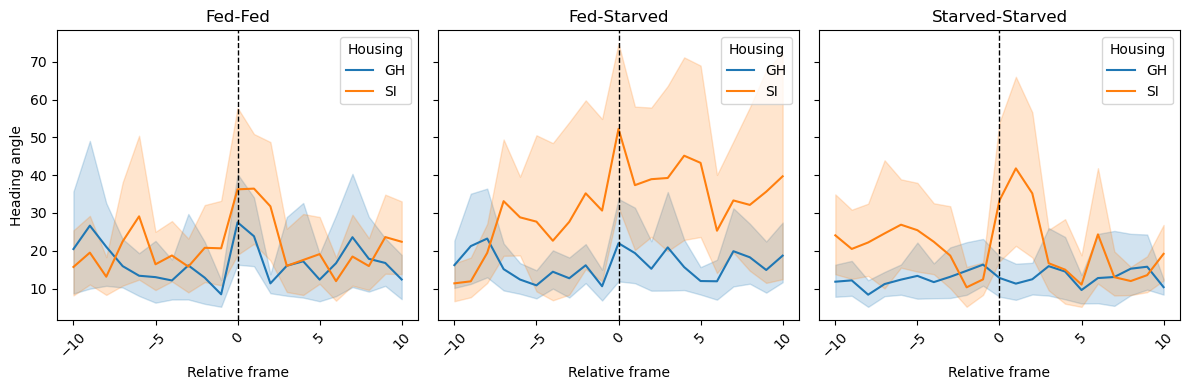

In [ ]:
first_interaction = file_larva_timecourse[
    file_larva_timecourse['interaction_group'] == 'first'
].copy()

# make simpler grouping columns
first_interaction['Housing'] = np.where(
    first_interaction['Condition'].str.contains('GH'),
    'GH',
    'SI'
)

first_interaction['Feeding'] = (
    first_interaction['Condition']
    .str.replace('GH ', '', regex=False)
    .str.replace('SI ', '', regex=False)
)

feeding_order = ['Fed-Fed', 'Fed-Starved', 'Starved-Starved']

fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True, sharex=True)

for ax, feeding in zip(axes, feeding_order):

    sub = first_interaction[first_interaction['Feeding'] == feeding]

    sns.lineplot(
        data=sub,
        x='rel_frame',
        y='heading_angle',
        hue='Housing',
        hue_order=['GH', 'SI'],
        errorbar=('ci', 95),
        ax=ax
    )

    ax.axvline(0, color='black', linestyle='--', linewidth=1)
    ax.set_title(feeding)
    ax.set_xlabel('Relative frame')
    ax.tick_params(axis='x', rotation=45)

axes[0].set_ylabel('Heading angle')
axes[1].set_ylabel('')
axes[2].set_ylabel('')

plt.tight_layout()
plt.show()

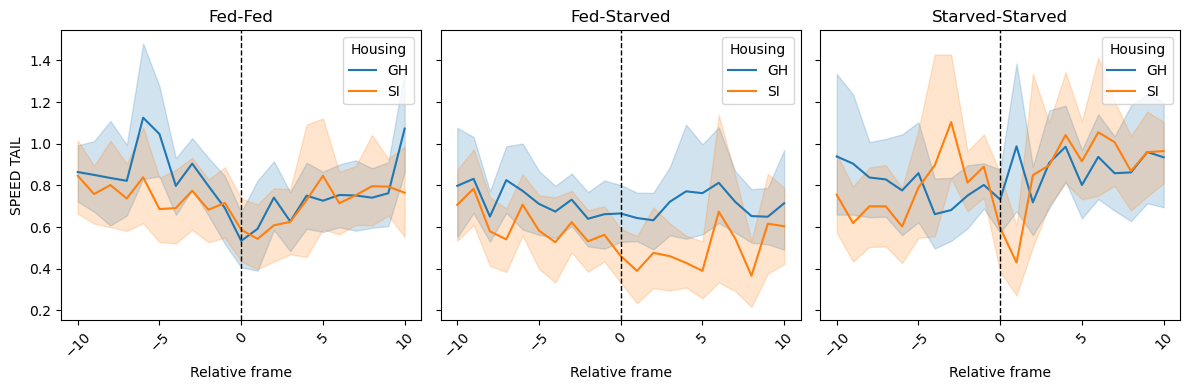

In [ ]:
first_interaction = file_larva_timecourse[
    file_larva_timecourse['interaction_group'] == 'first'
].copy()

# make simpler grouping columns
first_interaction['Housing'] = np.where(
    first_interaction['Condition'].str.contains('GH'),
    'GH',
    'SI'
)

first_interaction['Feeding'] = (
    first_interaction['Condition']
    .str.replace('GH ', '', regex=False)
    .str.replace('SI ', '', regex=False)
)

feeding_order = ['Fed-Fed', 'Fed-Starved', 'Starved-Starved']

fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True, sharex=True)

for ax, feeding in zip(axes, feeding_order):

    sub = first_interaction[first_interaction['Feeding'] == feeding]

    sns.lineplot(
        data=sub,
        x='rel_frame',
        y='speed_tail',
        hue='Housing',
        hue_order=['GH', 'SI'],
        errorbar=('ci', 95),
        ax=ax
    )

    ax.axvline(0, color='black', linestyle='--', linewidth=1)
    ax.set_title(feeding)
    ax.set_xlabel('Relative frame')
    ax.tick_params(axis='x', rotation=45)

axes[0].set_ylabel('SPEED TAIL')
axes[1].set_ylabel('')
axes[2].set_ylabel('')

plt.tight_layout()
plt.show()

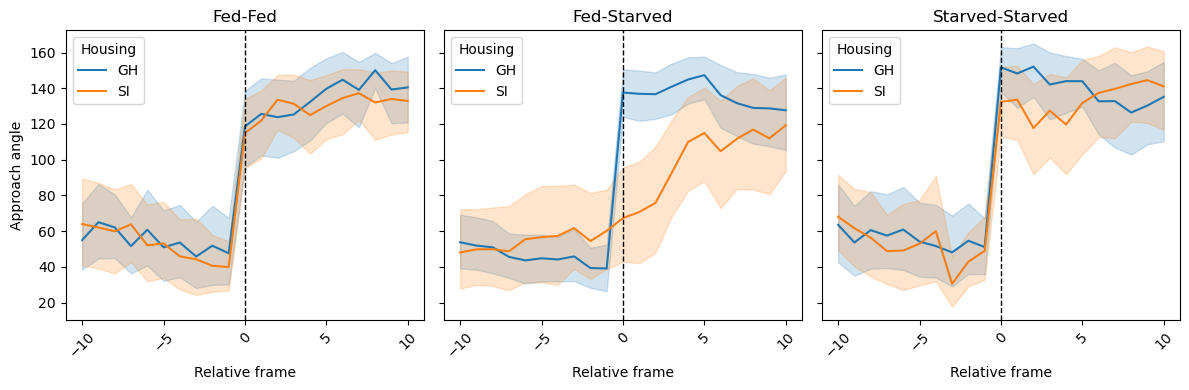

In [ ]:
first_interaction = file_larva_timecourse[
    file_larva_timecourse['interaction_group'] == 'first'
].copy()

# make simpler grouping columns
first_interaction['Housing'] = np.where(
    first_interaction['Condition'].str.contains('GH'),
    'GH',
    'SI'
)

first_interaction['Feeding'] = (
    first_interaction['Condition']
    .str.replace('GH ', '', regex=False)
    .str.replace('SI ', '', regex=False)
)

feeding_order = ['Fed-Fed', 'Fed-Starved', 'Starved-Starved']

fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True, sharex=True)

for ax, feeding in zip(axes, feeding_order):

    sub = first_interaction[first_interaction['Feeding'] == feeding]

    sns.lineplot(
        data=sub,
        x='rel_frame',
        y='approach_angle',
        hue='Housing',
        hue_order=['GH', 'SI'],
        errorbar=('ci', 95),
        ax=ax
    )

    ax.axvline(0, color='black', linestyle='--', linewidth=1)
    ax.set_title(feeding)
    ax.set_xlabel('Relative frame')
    ax.tick_params(axis='x', rotation=45)

axes[0].set_ylabel('Approach angle')
axes[1].set_ylabel('')
axes[2].set_ylabel('')

plt.tight_layout()
plt.show()

# OTHER INTERACTIONS

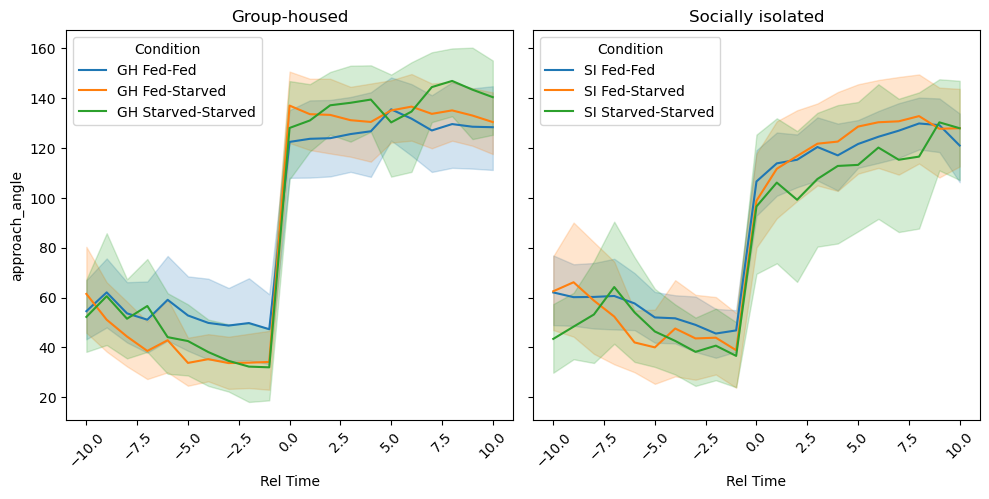

In [ ]:
other_interaction = file_larva_timecourse[file_larva_timecourse['interaction_group'] == 'other']

other_interaction_si = other_interaction[other_interaction['Condition'].str.contains('SI')].copy()
otjer_interaction_gh = other_interaction[other_interaction['Condition'].str.contains('GH')].copy()

fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=True)

# ---------------- GH ----------------
sns.lineplot(
    data=otjer_interaction_gh,
    x='rel_frame',
    y='approach_angle',
    hue='Condition',
    ax=axes[0]
)

axes[0].set_title('Group-housed')
axes[0].set_xlabel('Rel Time')
axes[0].set_ylabel('approach_angle')
axes[0].tick_params(axis='x', rotation=45)

# ---------------- SI ----------------
sns.lineplot(
    data=other_interaction_si,
    x='rel_frame',
    y='approach_angle',
    hue='Condition',
    ax=axes[1]
)

axes[1].set_title('Socially isolated')
axes[1].set_xlabel('Rel Time')
axes[1].set_ylabel('')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

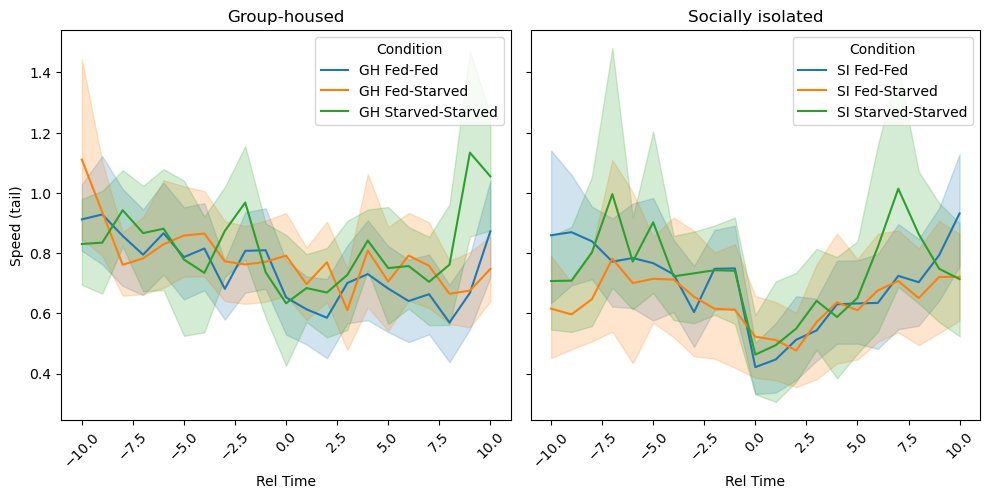

In [ ]:
other_interaction = file_larva_timecourse[file_larva_timecourse['interaction_group'] == 'other']

other_interaction_si = other_interaction[other_interaction['Condition'].str.contains('SI')].copy()
otjer_interaction_gh = other_interaction[other_interaction['Condition'].str.contains('GH')].copy()

fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=True)

# ---------------- GH ----------------
sns.lineplot(
    data=otjer_interaction_gh,
    x='rel_frame',
    y='speed_tail',
    hue='Condition',
    ax=axes[0]
)

axes[0].set_title('Group-housed')
axes[0].set_xlabel('Rel Time')
axes[0].set_ylabel('Speed (tail)')
axes[0].tick_params(axis='x', rotation=45)

# ---------------- SI ----------------
sns.lineplot(
    data=other_interaction_si,
    x='rel_frame',
    y='speed_tail',
    hue='Condition',
    ax=axes[1]
)

axes[1].set_title('Socially isolated')
axes[1].set_xlabel('Rel Time')
axes[1].set_ylabel('')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

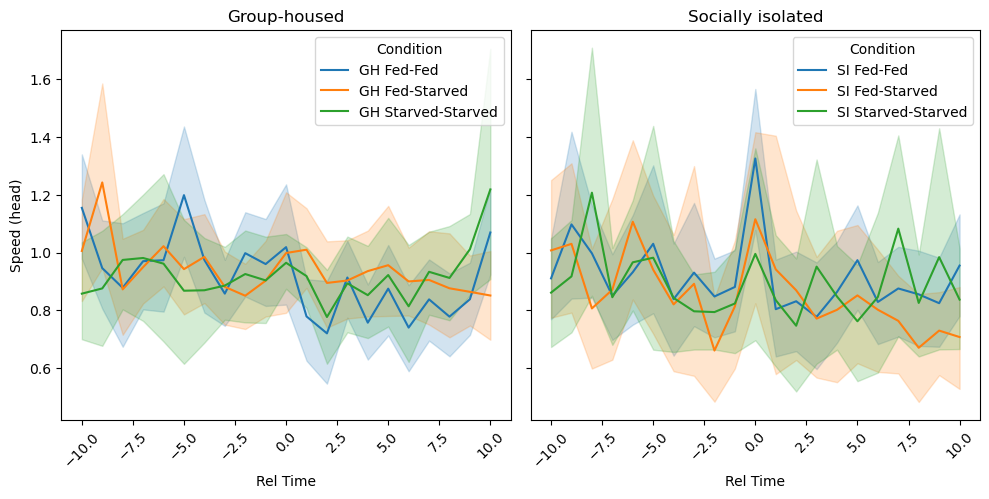

In [ ]:
other_interaction = file_larva_timecourse[file_larva_timecourse['interaction_group'] == 'other']

other_interaction_si = other_interaction[other_interaction['Condition'].str.contains('SI')].copy()
otjer_interaction_gh = other_interaction[other_interaction['Condition'].str.contains('GH')].copy()

fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=True)

# ---------------- GH ----------------
sns.lineplot(
    data=otjer_interaction_gh,
    x='rel_frame',
    y='speed_head',
    hue='Condition',
    ax=axes[0]
)

axes[0].set_title('Group-housed')
axes[0].set_xlabel('Rel Time')
axes[0].set_ylabel('Speed (head)')
axes[0].tick_params(axis='x', rotation=45)

# ---------------- SI ----------------
sns.lineplot(
    data=other_interaction_si,
    x='rel_frame',
    y='speed_head',
    hue='Condition',
    ax=axes[1]
)

axes[1].set_title('Socially isolated')
axes[1].set_xlabel('Rel Time')
axes[1].set_ylabel('')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

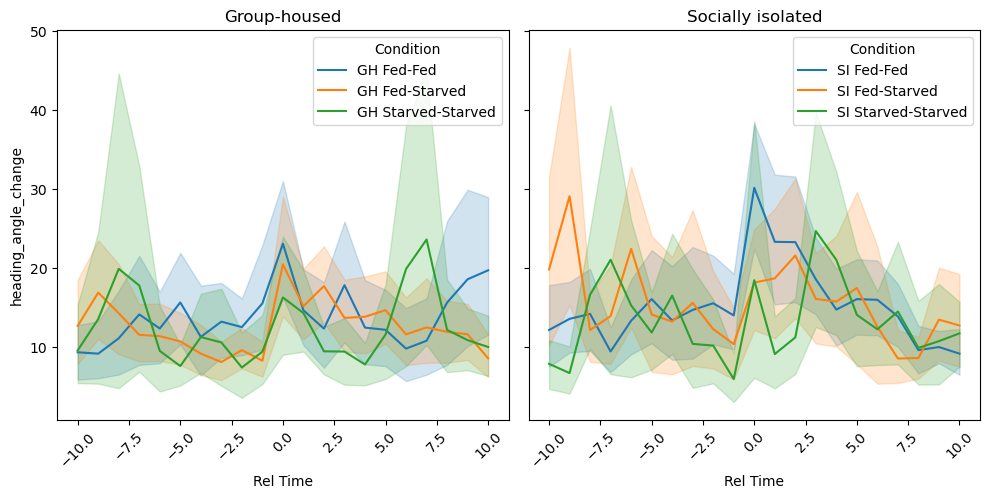

In [ ]:
other_interaction = file_larva_timecourse[file_larva_timecourse['interaction_group'] == 'other']

other_interaction_si = other_interaction[other_interaction['Condition'].str.contains('SI')].copy()
otjer_interaction_gh = other_interaction[other_interaction['Condition'].str.contains('GH')].copy()

fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=True)

# ---------------- GH ----------------
sns.lineplot(
    data=otjer_interaction_gh,
    x='rel_frame',
    y='heading_angle_change',
    hue='Condition',
    ax=axes[0]
)

axes[0].set_title('Group-housed')
axes[0].set_xlabel('Rel Time')
axes[0].set_ylabel('heading_angle_change')
axes[0].tick_params(axis='x', rotation=45)

# ---------------- SI ----------------
sns.lineplot(
    data=other_interaction_si,
    x='rel_frame',
    y='heading_angle_change',
    hue='Condition',
    ax=axes[1]
)

axes[1].set_title('Socially isolated')
axes[1].set_xlabel('Rel Time')
axes[1].set_ylabel('')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# ALL HEAD-HEAD INTERACTIONS (MIXED FIRST AND OTHER)

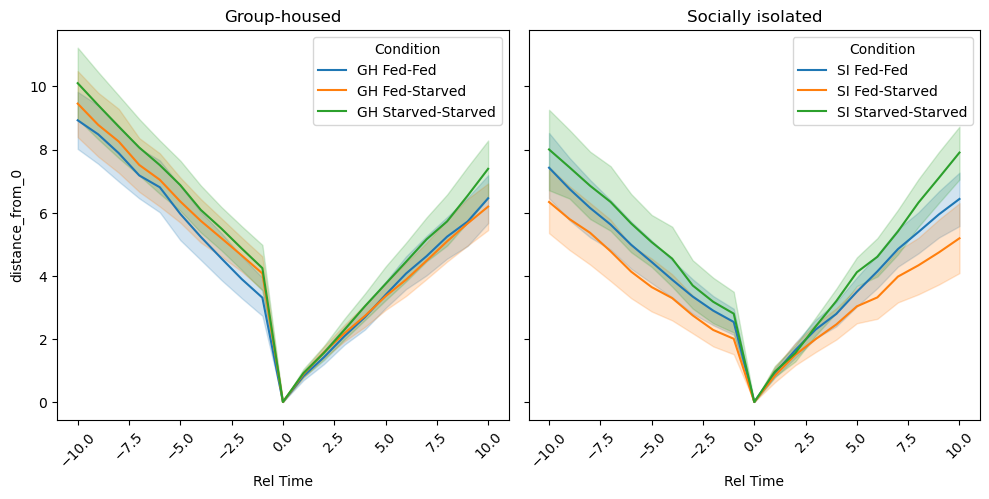

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=True)

# ---------------- GH ----------------
sns.lineplot(
    data=gh_file_larva_timecourse,
    x='rel_frame',
    y='distance_from_0',
    hue='Condition',
    ax=axes[0]
)

axes[0].set_title('Group-housed')
axes[0].set_xlabel('Rel Time')
axes[0].set_ylabel('distance_from_0')
axes[0].tick_params(axis='x', rotation=45)

# ---------------- SI ----------------
sns.lineplot(
    data=si_file_larva_timecourse,
    x='rel_frame',
    y='distance_from_0',
    hue='Condition',
    ax=axes[1]
)

axes[1].set_title('Socially isolated')
axes[1].set_xlabel('Rel Time')
axes[1].set_ylabel('')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

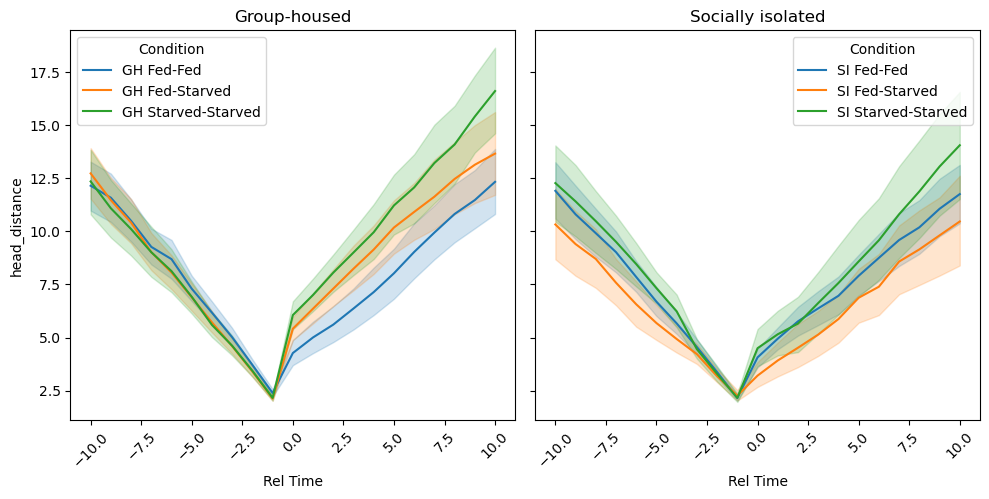

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=True)

# ---------------- GH ----------------
sns.lineplot(
    data=gh_file_larva_timecourse,
    x='rel_frame',
    y='head_distance',
    hue='Condition',
    ax=axes[0]
)

axes[0].set_title('Group-housed')
axes[0].set_xlabel('Rel Time')
axes[0].set_ylabel('head_distance')
axes[0].tick_params(axis='x', rotation=45)

# ---------------- SI ----------------
sns.lineplot(
    data=si_file_larva_timecourse,
    x='rel_frame',
    y='head_distance',
    hue='Condition',
    ax=axes[1]
)

axes[1].set_title('Socially isolated')
axes[1].set_xlabel('Rel Time')
axes[1].set_ylabel('')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

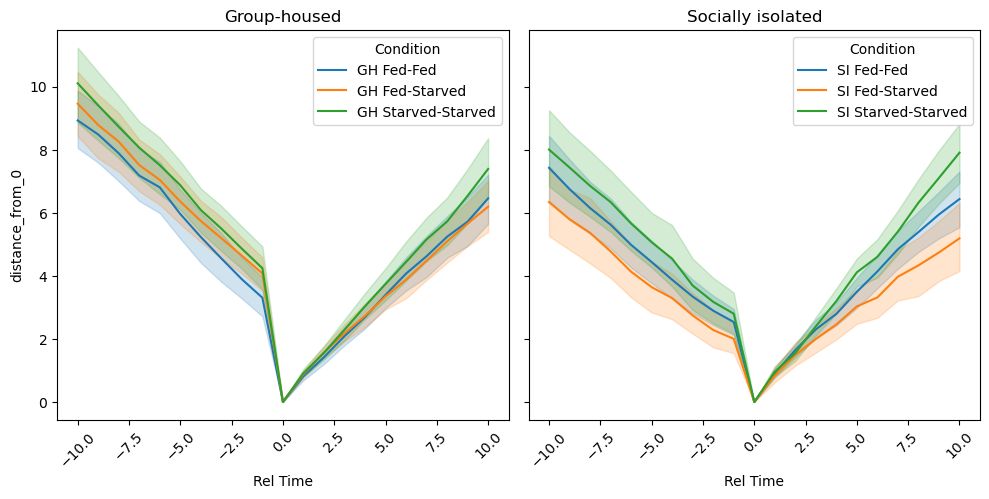

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=True)

# ---------------- GH ----------------
sns.lineplot(
    data=gh_file_larva_timecourse,
    x='rel_frame',
    y='distance_from_0',
    hue='Condition',
    ax=axes[0]
)

axes[0].set_title('Group-housed')
axes[0].set_xlabel('Rel Time')
axes[0].set_ylabel('distance_from_0')
axes[0].tick_params(axis='x', rotation=45)

# ---------------- SI ----------------
sns.lineplot(
    data=si_file_larva_timecourse,
    x='rel_frame',
    y='distance_from_0',
    hue='Condition',
    ax=axes[1]
)

axes[1].set_title('Socially isolated')
axes[1].set_xlabel('Rel Time')
axes[1].set_ylabel('')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

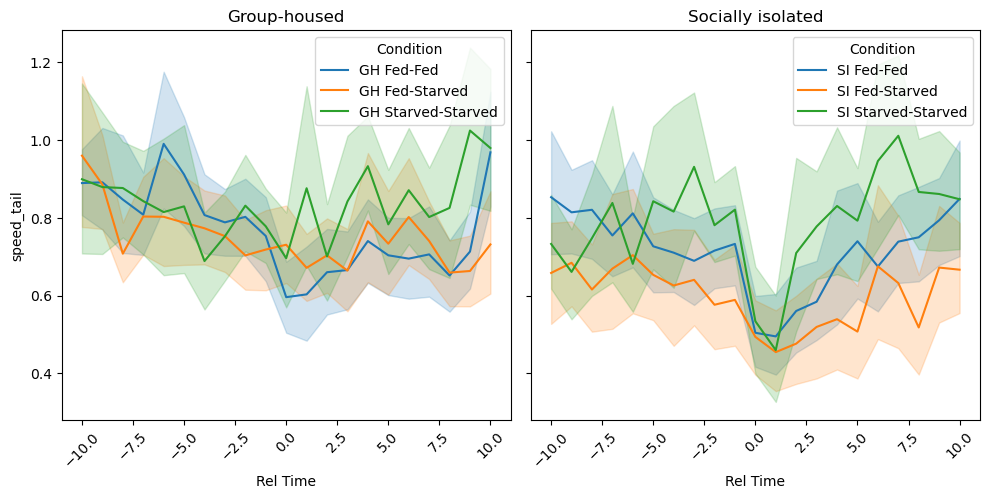

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=True)

# ---------------- GH ----------------
sns.lineplot(
    data=gh_file_larva_timecourse,
    x='rel_frame',
    y='speed_tail',
    hue='Condition',
    ax=axes[0]
)

axes[0].set_title('Group-housed')
axes[0].set_xlabel('Rel Time')
axes[0].set_ylabel('speed_tail')
axes[0].tick_params(axis='x', rotation=45)

# ---------------- SI ----------------
sns.lineplot(
    data=si_file_larva_timecourse,
    x='rel_frame',
    y='speed_tail',
    hue='Condition',
    ax=axes[1]
)

axes[1].set_title('Socially isolated')
axes[1].set_xlabel('Rel Time')
axes[1].set_ylabel('')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

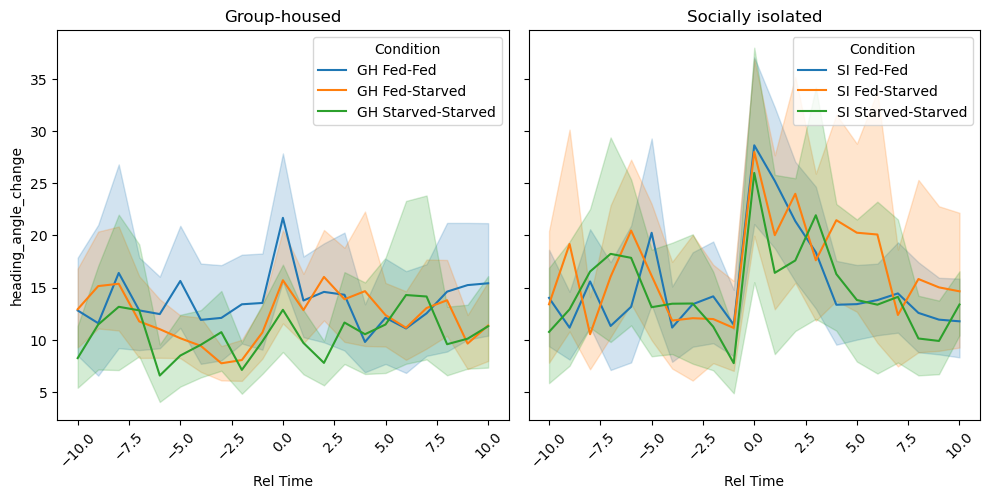

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=True)

# ---------------- GH ----------------
sns.lineplot(
    data=gh_file_larva_timecourse,
    x='rel_frame',
    y='heading_angle_change',
    hue='Condition',
    ax=axes[0]
)

axes[0].set_title('Group-housed')
axes[0].set_xlabel('Rel Time')
axes[0].set_ylabel('heading_angle_change')
axes[0].tick_params(axis='x', rotation=45)

# ---------------- SI ----------------
sns.lineplot(
    data=si_file_larva_timecourse,
    x='rel_frame',
    y='heading_angle_change',
    hue='Condition',
    ax=axes[1]
)

axes[1].set_title('Socially isolated')
axes[1].set_xlabel('Rel Time')
axes[1].set_ylabel('')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# STARVED VERSUS FED IN FED-STARVED CONDITION

In [113]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sys
import matplotlib.patches as mpatches
import matplotlib as mpl


# ---- Adobe-friendly fonts (must be set BEFORE plotting) ----
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42



df1 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/group-housed/fed-starved/head_head_contacts_kinematics_over_time_nocontacts_ref-window10.csv')
df1['Condition'] = 'GH'

df2 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/socially-isolated/fed-starved/head_head_contacts_kinematics_over_time_nocontacts_ref-window10.csv')
df2['Condition'] = 'SI'


df = pd.concat([df1, df2], ignore_index=True)

df['interaction_group'] = np.select(
    [
        (df['interaction_number'] == 1) & (df['interaction_frame'] < 1200),
        (df['interaction_number'] == 1) & (df['interaction_frame'] >= 1200),
    ],
    [
        'first',
        'not_viable_first',
    ],
    default='other'
)
df = df[df['interaction_group'] != 'not_viable_first'].copy()


df['role'] = df['track_id'].map({0: 'starved', 1: 'fed'})

df = df.sort_values(['Condition','file', 'track_id', 'rel_frame'])


si = df[df['Condition'] == 'SI'].copy()
gh = df[df['Condition'] == 'GH'].copy()

metrics = ['speed_head', 'speed_body', 'speed_tail', 'heading_angle', 'heading_angle_change', 'approach_angle', 'approach_angle_head', 'cum_distance_start', 'cum_distance_0', 'distance_from_0', 'directional_alignment_cosine', 'track0_projection_onto_track1', 'head_distance']

file_larva_timecourse = (
    df.groupby(['Condition', 'file', 'track_id', 'role', 'interaction_group', 'rel_frame'])[metrics]
      .mean()
      .reset_index()
)



# FIRST INTERACTION

/Users/cochral/miniconda3/envs/maggots/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_43987/1913874345.py:22: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


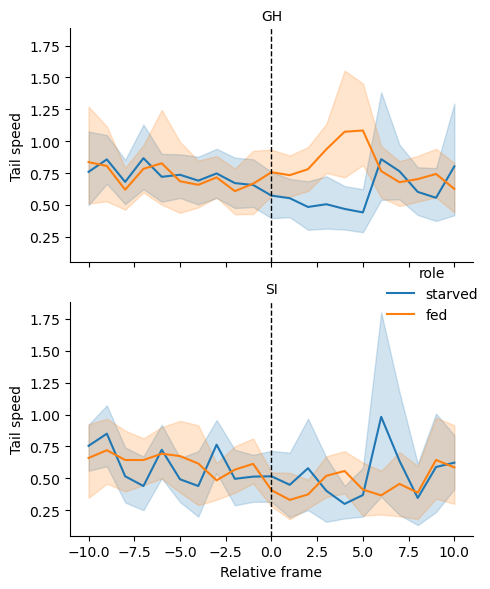

In [114]:
first_interaction = file_larva_timecourse[file_larva_timecourse['interaction_group'] == 'first']


g = sns.relplot(
    data=first_interaction,
    x='rel_frame',
    y='speed_tail',
    hue='role',
    row='Condition',
    kind='line',
    errorbar=('ci', 95),
    height=3,
    aspect=1.3
)

g.set_axis_labels('Relative frame', 'Tail speed')
g.set_titles(row_template='{row_name}', col_template='{col_name}')

for ax in g.axes.flat:
    ax.axvline(0, color='black', linestyle='--', linewidth=1)

plt.tight_layout()
plt.show()


/Users/cochral/miniconda3/envs/maggots/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_43987/3261772041.py:22: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


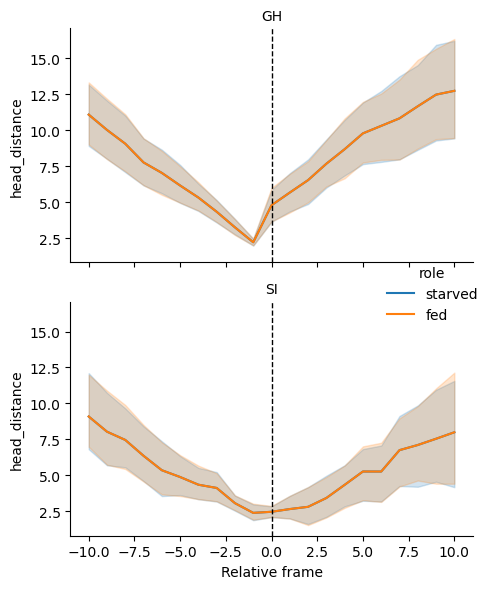

In [ ]:
first_interaction = file_larva_timecourse[file_larva_timecourse['interaction_group'] == 'first']


g = sns.relplot(
    data=first_interaction,
    x='rel_frame',
    y='head_distance',
    hue='role',
    row='Condition',
    kind='line',
    errorbar=('ci', 95),
    height=3,
    aspect=1.3
)

g.set_axis_labels('Relative frame', 'head_distance')
g.set_titles(row_template='{row_name}', col_template='{col_name}')

for ax in g.axes.flat:
    ax.axvline(0, color='black', linestyle='--', linewidth=1)

plt.tight_layout()
plt.show()


/Users/cochral/miniconda3/envs/maggots/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_43987/1163735768.py:19: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


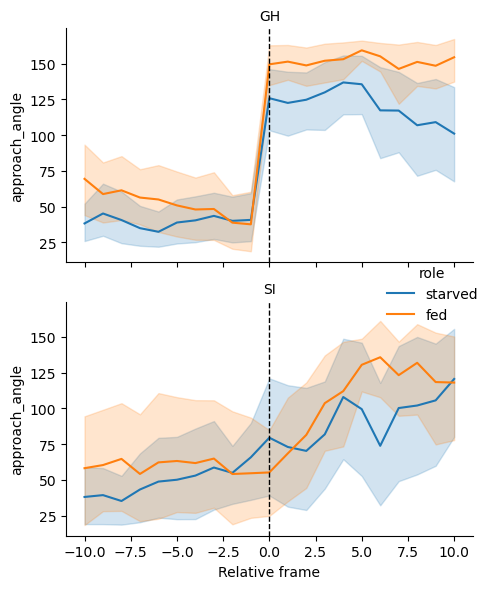

In [ ]:
g = sns.relplot(
    data=first_interaction,
    x='rel_frame',
    y='approach_angle',
    hue='role',
    row='Condition',
    kind='line',
    errorbar=('ci', 95),
    height=3,
    aspect=1.3
)

g.set_axis_labels('Relative frame', 'approach_angle')
g.set_titles(row_template='{row_name}', col_template='{col_name}')

for ax in g.axes.flat:
    ax.axvline(0, color='black', linestyle='--', linewidth=1)

plt.tight_layout()
plt.show()


/Users/cochral/miniconda3/envs/maggots/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_43987/3646864221.py:19: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


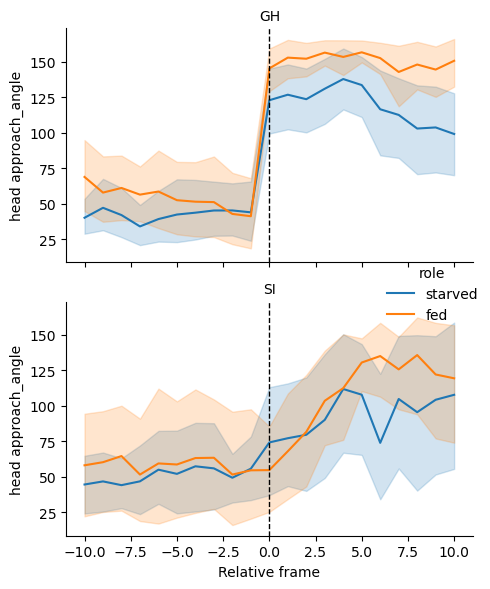

In [ ]:
g = sns.relplot(
    data=first_interaction,
    x='rel_frame',
    y='approach_angle_head',
    hue='role',
    row='Condition',
    kind='line',
    errorbar=('ci', 95),
    height=3,
    aspect=1.3
)

g.set_axis_labels('Relative frame', 'head approach_angle')
g.set_titles(row_template='{row_name}', col_template='{col_name}')

for ax in g.axes.flat:
    ax.axvline(0, color='black', linestyle='--', linewidth=1)

plt.tight_layout()
plt.show()


/Users/cochral/miniconda3/envs/maggots/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_43987/1169788824.py:19: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


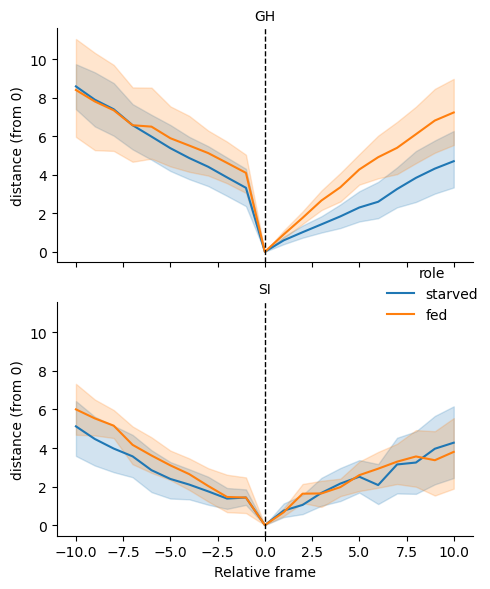

In [ ]:
g = sns.relplot(
    data=first_interaction,
    x='rel_frame',
    y='distance_from_0',
    hue='role',
    row='Condition',
    kind='line',
    errorbar=('ci', 95),
    height=3,
    aspect=1.3
)

g.set_axis_labels('Relative frame', 'distance (from 0)')
g.set_titles(row_template='{row_name}', col_template='{col_name}')

for ax in g.axes.flat:
    ax.axvline(0, color='black', linestyle='--', linewidth=1)

plt.tight_layout()
plt.show()


/Users/cochral/miniconda3/envs/maggots/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_43987/1150362956.py:19: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


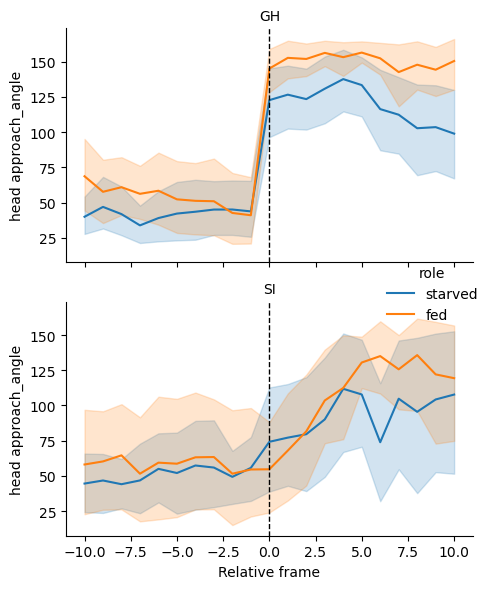

In [ ]:



g = sns.relplot(
    data=first_interaction,
    x='rel_frame',
    y='approach_angle_head',
    hue='role',
    row='Condition',
    kind='line',
    errorbar=('ci', 95),
    height=3,
    aspect=1.3
)

g.set_axis_labels('Relative frame', 'head approach_angle')
g.set_titles(row_template='{row_name}', col_template='{col_name}')

for ax in g.axes.flat:
    ax.axvline(0, color='black', linestyle='--', linewidth=1)

plt.tight_layout()
plt.show()


/Users/cochral/miniconda3/envs/maggots/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_43987/3781664598.py:19: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


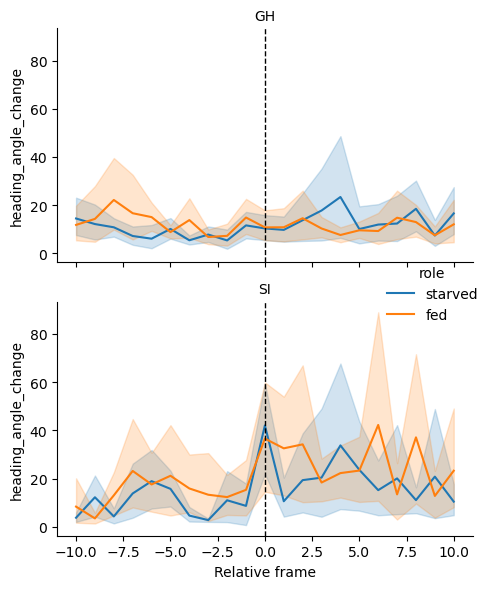

In [ ]:
g = sns.relplot(
    data=first_interaction,
    x='rel_frame',
    y='heading_angle_change',
    hue='role',
    row='Condition',
    kind='line',
    errorbar=('ci', 95),
    height=3,
    aspect=1.3
)

g.set_axis_labels('Relative frame', 'heading_angle_change')
g.set_titles(row_template='{row_name}', col_template='{col_name}')

for ax in g.axes.flat:
    ax.axvline(0, color='black', linestyle='--', linewidth=1)

plt.tight_layout()
plt.show()


/Users/cochral/miniconda3/envs/maggots/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_43987/1137134309.py:19: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


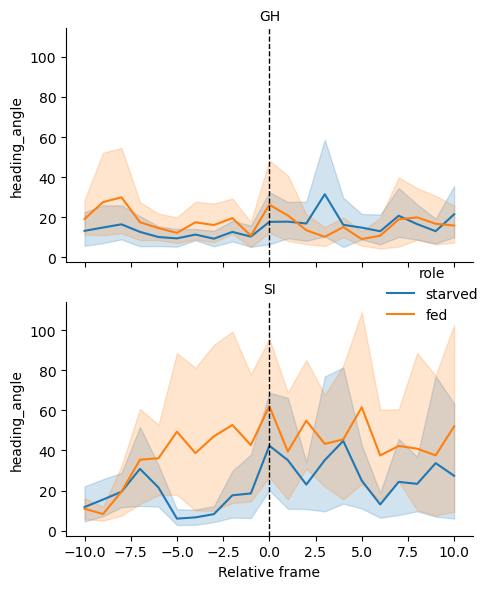

In [115]:
g = sns.relplot(
    data=first_interaction,
    x='rel_frame',
    y='heading_angle',
    hue='role',
    row='Condition',
    kind='line',
    errorbar=('ci', 95),
    height=3,
    aspect=1.3
)

g.set_axis_labels('Relative frame', 'heading_angle')
g.set_titles(row_template='{row_name}', col_template='{col_name}')

for ax in g.axes.flat:
    ax.axvline(0, color='black', linestyle='--', linewidth=1)

plt.tight_layout()
plt.show()


# OTHER INTERACTION

/Users/cochral/miniconda3/envs/maggots/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_43987/4044528619.py:24: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


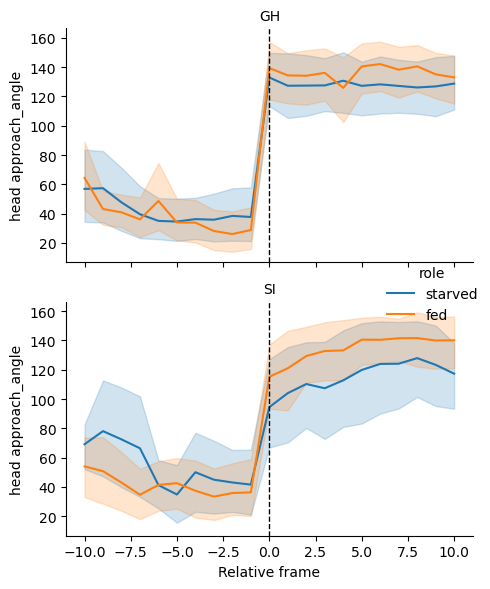

In [ ]:
other_interaction = file_larva_timecourse[file_larva_timecourse['interaction_group'] == 'other']




g = sns.relplot(
    data=other_interaction,
    x='rel_frame',
    y='approach_angle_head',
    hue='role',
    row='Condition',
    kind='line',
    errorbar=('ci', 95),
    height=3,
    aspect=1.3
)

g.set_axis_labels('Relative frame', 'head approach_angle')
g.set_titles(row_template='{row_name}', col_template='{col_name}')

for ax in g.axes.flat:
    ax.axvline(0, color='black', linestyle='--', linewidth=1)

plt.tight_layout()
plt.show()



/Users/cochral/miniconda3/envs/maggots/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_43987/3641183828.py:19: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


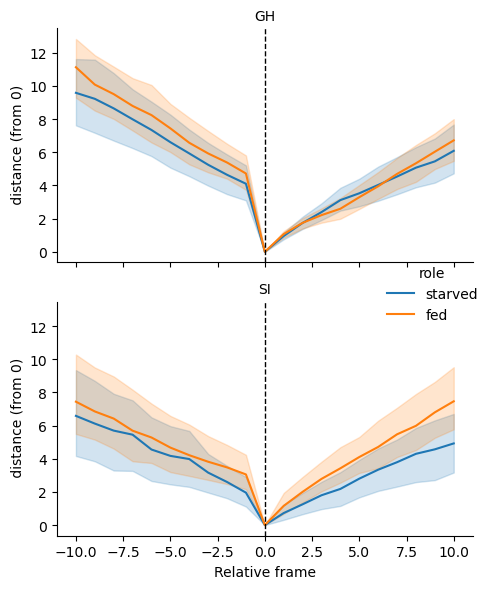

In [ ]:
g = sns.relplot(
    data=other_interaction,
    x='rel_frame',
    y='distance_from_0',
    hue='role',
    row='Condition',
    kind='line',
    errorbar=('ci', 95),
    height=3,
    aspect=1.3
)

g.set_axis_labels('Relative frame', ' distance (from 0)')
g.set_titles(row_template='{row_name}', col_template='{col_name}')

for ax in g.axes.flat:
    ax.axvline(0, color='black', linestyle='--', linewidth=1)

plt.tight_layout()
plt.show()


/Users/cochral/miniconda3/envs/maggots/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_43987/1997616002.py:19: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


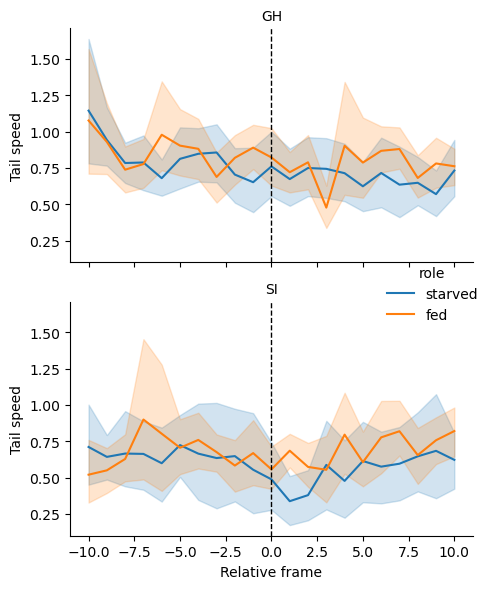

In [ ]:
g = sns.relplot(
    data=other_interaction,
    x='rel_frame',
    y='speed_tail',
    hue='role',
    row='Condition',
    kind='line',
    errorbar=('ci', 95),
    height=3,
    aspect=1.3
)

g.set_axis_labels('Relative frame', 'Tail speed')
g.set_titles(row_template='{row_name}', col_template='{col_name}')

for ax in g.axes.flat:
    ax.axvline(0, color='black', linestyle='--', linewidth=1)

plt.tight_layout()
plt.show()

# COMPARING STARVED LARVAE FROM FED-STARVED AND THE STARVED CONDITION

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sys
import matplotlib.patches as mpatches
import matplotlib as mpl


# ---- Adobe-friendly fonts (must be set BEFORE plotting) ----
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42



df1 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/group-housed/fed-starved/head_head_contacts_kinematics_over_time_nocontacts_ref-window10.csv')
df1['Condition'] = 'GH Fed-Starved'

df2 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/socially-isolated/fed-starved/head_head_contacts_kinematics_over_time_nocontacts_ref-window10.csv')
df2['Condition'] = 'SI Fed-Starved'



# ---- REAL STARVED-STARVED ----
df3 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/group-housed/starved-starved/head_head_contacts_kinematics_over_time_nocontacts_ref-window10.csv')
df3['Condition'] = 'GH Starved-Starved'

df4 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/socially-isolated/starved-starved/head_head_contacts_kinematics_over_time_nocontacts_ref-window10.csv')
df4['Condition'] = 'SI Starved-Starved'


# combine all
df = pd.concat([df1, df2, df3, df4], ignore_index=True)

df['interaction_group'] = np.select(
    [
        (df['interaction_number'] == 1) & (df['interaction_frame'] < 1200),
        (df['interaction_number'] == 1) & (df['interaction_frame'] >= 1200),
    ],
    [
        'first',
        'not_viable_first',
    ],
    default='other'
)
df = df[df['interaction_group'] != 'not_viable_first'].copy()


df['role'] = df['track_id'].map({0: 'starved', 1: 'fed'})

df.loc[df['Condition'].str.contains('Starved-Starved'), 'role'] = 'starved'


df = df.sort_values(['Condition','file', 'track_id', 'rel_frame'])

df = df[df['role'] == 'starved'].copy()

si = df[df['Condition'].str.contains('SI')].copy()
gh = df[df['Condition'].str.contains('GH')].copy()

metrics = ['speed_head', 'speed_body', 'speed_tail', 'heading_angle', 'heading_angle_change', 'approach_angle', 'approach_angle_head', 'cum_distance_start', 'cum_distance_0', 'distance_from_0', 'directional_alignment_cosine', 'track0_projection_onto_track1', 'head_distance']

file_larva_timecourse = (
    df.groupby(['Condition', 'file', 'track_id', 'role', 'interaction_group', 'rel_frame'])[metrics]
      .mean()
      .reset_index()
)

si_file_larva_timecourse = file_larva_timecourse[file_larva_timecourse['Condition'].str.contains('SI')].copy()
gh_file_larva_timecourse = file_larva_timecourse[file_larva_timecourse['Condition'].str.contains('GH')].copy()


si_first_interaction = si_file_larva_timecourse[si_file_larva_timecourse['interaction_group'] == 'first']
gh_first_interaction = gh_file_larva_timecourse[gh_file_larva_timecourse['interaction_group'] == 'first']

si_other_interaction = si_file_larva_timecourse[si_file_larva_timecourse['interaction_group'] == 'other']
gh_other_interaction = gh_file_larva_timecourse[gh_file_larva_timecourse['interaction_group'] == 'other']


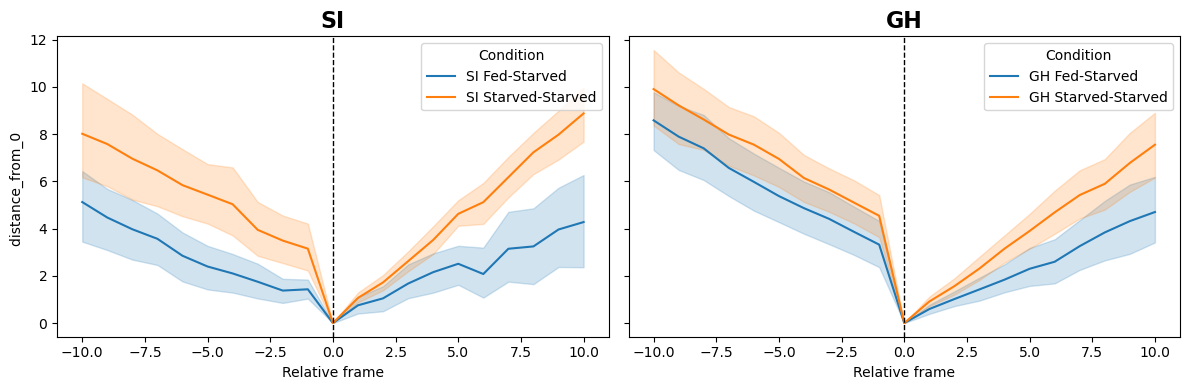

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12,4), sharey=True)

# ---------------- SI ----------------
sns.lineplot(
    data=si_first_interaction,
    x='rel_frame',
    y='distance_from_0',
    hue='Condition',
    errorbar=('ci', 95),
    ax=axes[0]
)

axes[0].axvline(0, color='black', linestyle='--', linewidth=1)
axes[0].set_title('SI', fontsize=16, fontweight='bold')
axes[0].set_xlabel('Relative frame')
axes[0].set_ylabel('distance_from_0 ')

# ---------------- GH ----------------
sns.lineplot(
    data=gh_first_interaction,
    x='rel_frame',
    y='distance_from_0',
    hue='Condition',
    errorbar=('ci', 95),
    ax=axes[1]
)

axes[1].axvline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_title('GH', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Relative frame')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

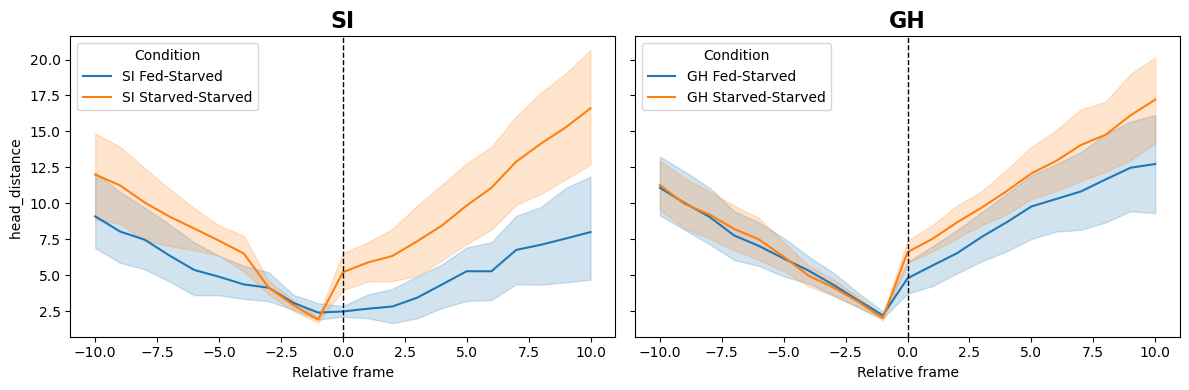

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12,4), sharey=True)

# ---------------- SI ----------------
sns.lineplot(
    data=si_first_interaction,
    x='rel_frame',
    y='head_distance',
    hue='Condition',
    errorbar=('ci', 95),
    ax=axes[0]
)

axes[0].axvline(0, color='black', linestyle='--', linewidth=1)
axes[0].set_title('SI', fontsize=16, fontweight='bold')
axes[0].set_xlabel('Relative frame')
axes[0].set_ylabel('head_distance ')

# ---------------- GH ----------------
sns.lineplot(
    data=gh_first_interaction,
    x='rel_frame',
    y='head_distance',
    hue='Condition',
    errorbar=('ci', 95),
    ax=axes[1]
)

axes[1].axvline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_title('GH', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Relative frame')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

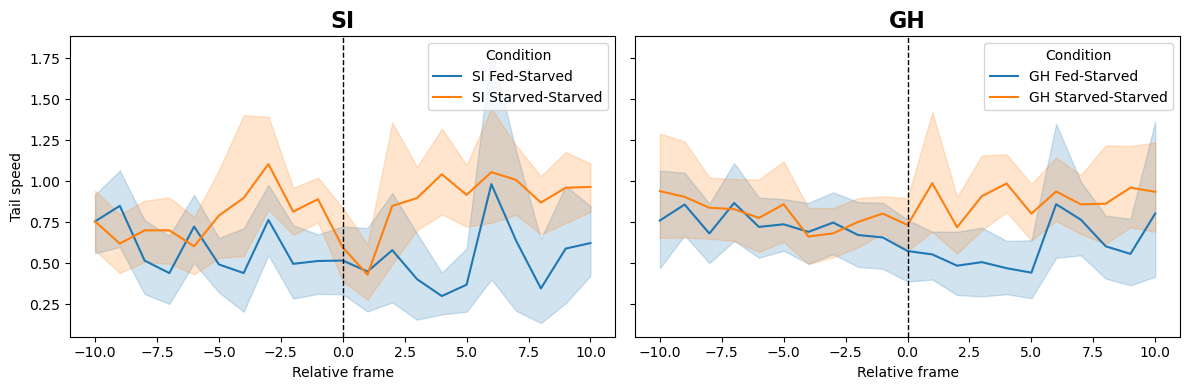

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12,4), sharey=True)

# ---------------- SI ----------------
sns.lineplot(
    data=si_first_interaction,
    x='rel_frame',
    y='speed_tail',
    hue='Condition',
    errorbar=('ci', 95),
    ax=axes[0]
)

axes[0].axvline(0, color='black', linestyle='--', linewidth=1)
axes[0].set_title('SI', fontsize=16, fontweight='bold')
axes[0].set_xlabel('Relative frame')
axes[0].set_ylabel('Tail speed')

# ---------------- GH ----------------
sns.lineplot(
    data=gh_first_interaction,
    x='rel_frame',
    y='speed_tail',
    hue='Condition',
    errorbar=('ci', 95),
    ax=axes[1]
)

axes[1].axvline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_title('GH', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Relative frame')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

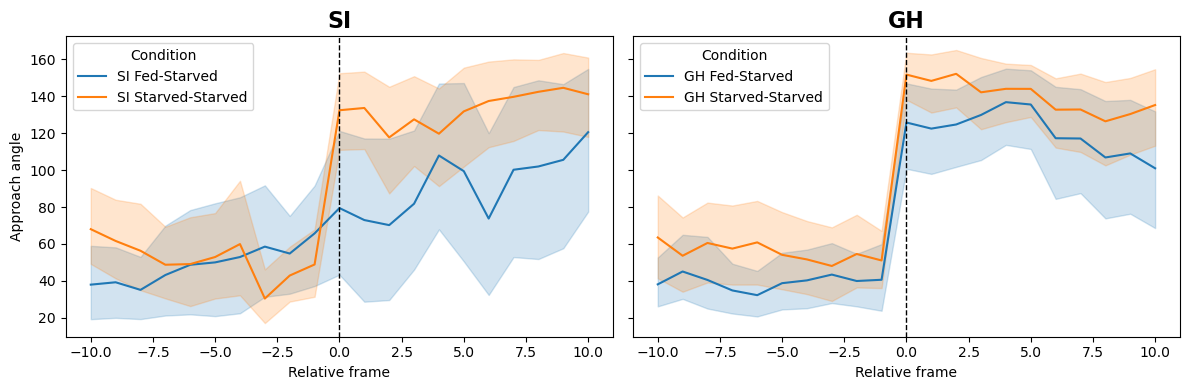

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12,4), sharey=True)

# ---------------- SI ----------------
sns.lineplot(
    data=si_first_interaction,
    x='rel_frame',
    y='approach_angle',
    hue='Condition',
    errorbar=('ci', 95),
    ax=axes[0]
)

axes[0].axvline(0, color='black', linestyle='--', linewidth=1)
axes[0].set_title('SI', fontsize=16, fontweight='bold')
axes[0].set_xlabel('Relative frame')
axes[0].set_ylabel('Approach angle')

# ---------------- GH ----------------
sns.lineplot(
    data=gh_first_interaction,
    x='rel_frame',
    y='approach_angle',
    hue='Condition',
    errorbar=('ci', 95),
    ax=axes[1]
)

axes[1].axvline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_title('GH', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Relative frame')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

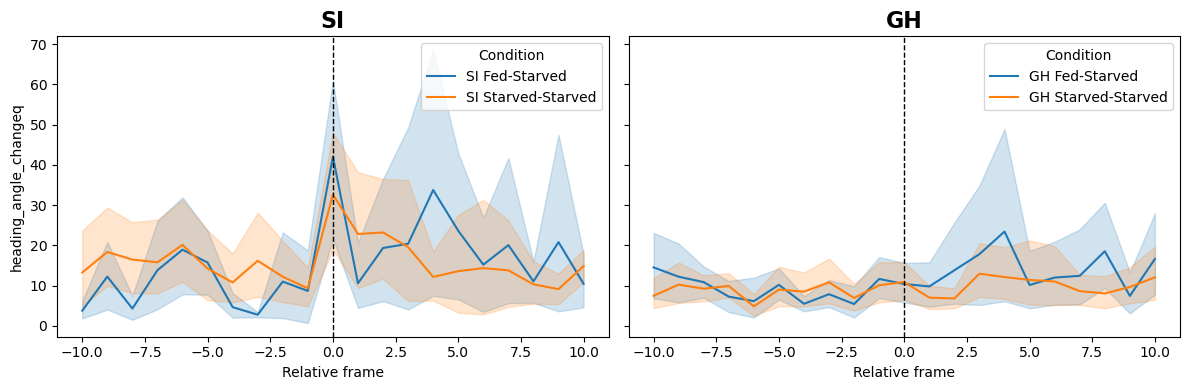

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12,4), sharey=True)

# ---------------- SI ----------------
sns.lineplot(
    data=si_first_interaction,
    x='rel_frame',
    y='heading_angle_change',
    hue='Condition',
    errorbar=('ci', 95),
    ax=axes[0]
)

axes[0].axvline(0, color='black', linestyle='--', linewidth=1)
axes[0].set_title('SI', fontsize=16, fontweight='bold')
axes[0].set_xlabel('Relative frame')
axes[0].set_ylabel('heading_angle_changeq')

# ---------------- GH ----------------
sns.lineplot(
    data=gh_first_interaction,
    x='rel_frame',
    y='heading_angle_change',
    hue='Condition',
    errorbar=('ci', 95),
    ax=axes[1]
)

axes[1].axvline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_title('GH', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Relative frame')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

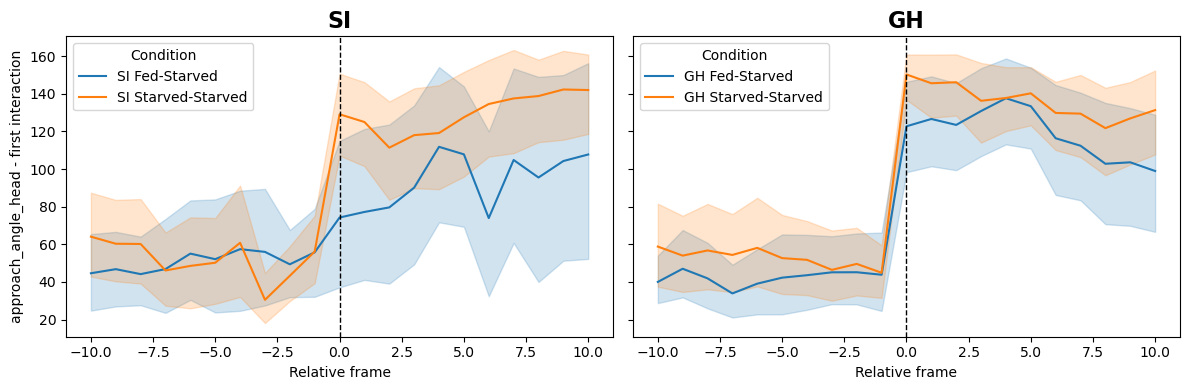

In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(12,4), sharey=True)

# ---------------- SI ----------------
sns.lineplot(
    data=si_first_interaction,
    x='rel_frame',
    y='approach_angle_head',
    hue='Condition',
    errorbar=('ci', 95),
    ax=axes[0]
)

axes[0].axvline(0, color='black', linestyle='--', linewidth=1)
axes[0].set_title('SI', fontsize=16, fontweight='bold')
axes[0].set_xlabel('Relative frame')
axes[0].set_ylabel('approach_angle_head - first interaction')

# ---------------- GH ----------------
sns.lineplot(
    data=gh_first_interaction,
    x='rel_frame',
    y='approach_angle_head',
    hue='Condition',
    errorbar=('ci', 95),
    ax=axes[1]
)

axes[1].axvline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_title('GH', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Relative frame')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

# OTHER

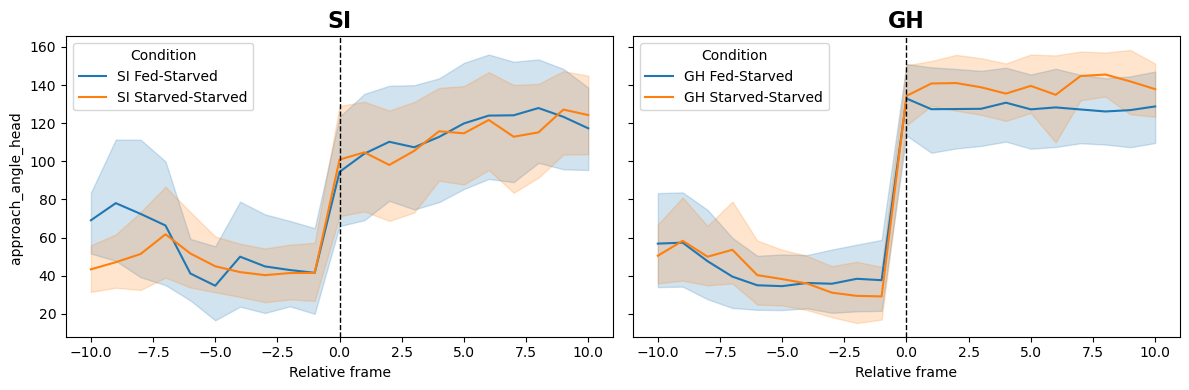

In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(12,4), sharey=True)

# ---------------- SI ----------------
sns.lineplot(
    data=si_other_interaction,
    x='rel_frame',
    y='approach_angle_head',
    hue='Condition',
    errorbar=('ci', 95),
    ax=axes[0]
)

axes[0].axvline(0, color='black', linestyle='--', linewidth=1)
axes[0].set_title('SI', fontsize=16, fontweight='bold')
axes[0].set_xlabel('Relative frame')
axes[0].set_ylabel('approach_angle_head ')

# ---------------- GH ----------------
sns.lineplot(
    data=gh_other_interaction,
    x='rel_frame',
    y='approach_angle_head',
    hue='Condition',
    errorbar=('ci', 95),
    ax=axes[1]
)

axes[1].axvline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_title('GH', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Relative frame')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

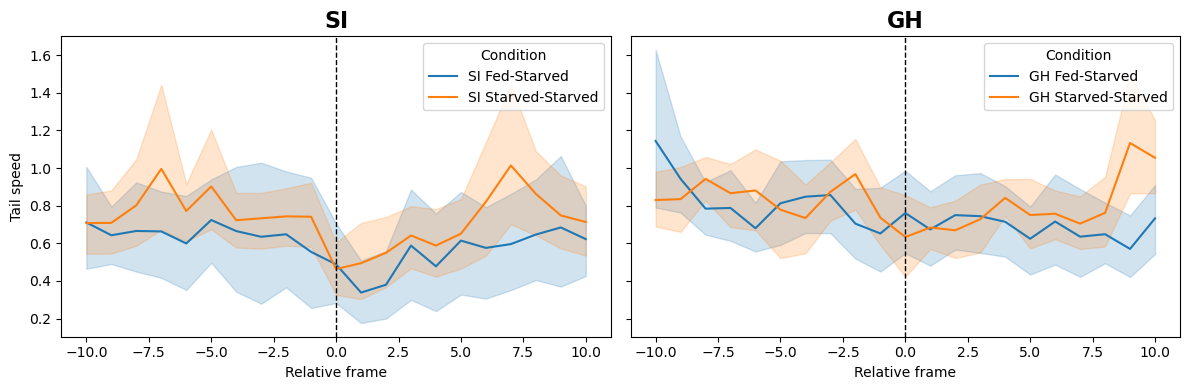

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12,4), sharey=True)

# ---------------- SI ----------------
sns.lineplot(
    data=si_other_interaction,
    x='rel_frame',
    y='speed_tail',
    hue='Condition',
    errorbar=('ci', 95),
    ax=axes[0]
)

axes[0].axvline(0, color='black', linestyle='--', linewidth=1)
axes[0].set_title('SI', fontsize=16, fontweight='bold')
axes[0].set_xlabel('Relative frame')
axes[0].set_ylabel('Tail speed')

# ---------------- GH ----------------
sns.lineplot(
    data=gh_other_interaction,
    x='rel_frame',
    y='speed_tail',
    hue='Condition',
    errorbar=('ci', 95),
    ax=axes[1]
)

axes[1].axvline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_title('GH', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Relative frame')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

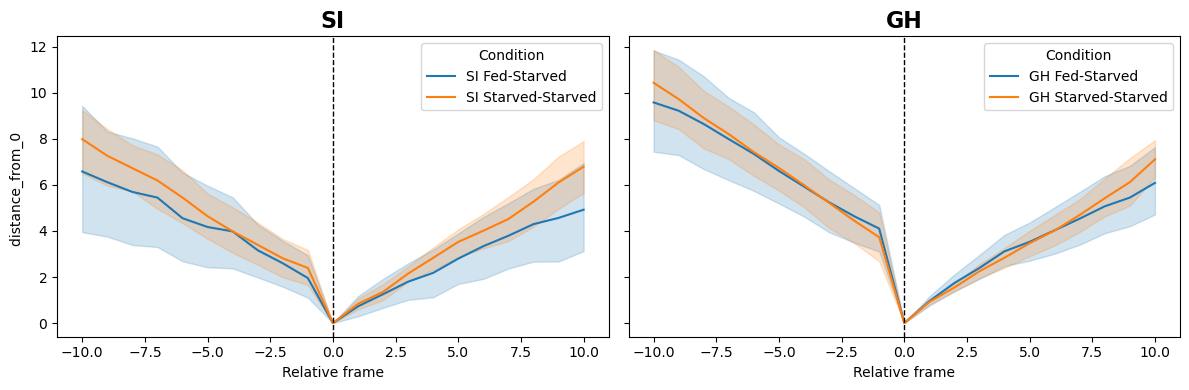

In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(12,4), sharey=True)

# ---------------- SI ----------------
sns.lineplot(
    data=si_other_interaction,
    x='rel_frame',
    y='distance_from_0',
    hue='Condition',
    errorbar=('ci', 95),
    ax=axes[0]
)

axes[0].axvline(0, color='black', linestyle='--', linewidth=1)
axes[0].set_title('SI', fontsize=16, fontweight='bold')
axes[0].set_xlabel('Relative frame')
axes[0].set_ylabel('distance_from_0 ')

# ---------------- GH ----------------
sns.lineplot(
    data=gh_other_interaction,
    x='rel_frame',
    y='distance_from_0',
    hue='Condition',
    errorbar=('ci', 95),
    ax=axes[1]
)

axes[1].axvline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_title('GH', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Relative frame')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

# COMPARING FED LARVAE FROM FED-STARVED AND THE FED CONDITION

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sys
import matplotlib.patches as mpatches
import matplotlib as mpl


# ---- Adobe-friendly fonts (must be set BEFORE plotting) ----
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42



df1 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/group-housed/fed-starved/head_head_contacts_kinematics_over_time_nocontacts_ref-window10.csv')
df1['Condition'] = 'GH Fed-Starved'

df2 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/socially-isolated/fed-starved/head_head_contacts_kinematics_over_time_nocontacts_ref-window10.csv')
df2['Condition'] = 'SI Fed-Starved'



# ---- REAL STARVED-STARVED ----
df3 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/group-housed/fed-fed/head_head_contacts_kinematics_over_time_nocontacts_ref-window10.csv')
df3['Condition'] = 'GH Fed-Fed'

df4 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/socially-isolated/fed-fed/head_head_contacts_kinematics_over_time_nocontacts_ref-window10.csv')
df4['Condition'] = 'SI Fed-Fed'


# combine all
df = pd.concat([df1, df2, df3, df4], ignore_index=True)

df['interaction_group'] = np.select(
    [
        (df['interaction_number'] == 1) & (df['interaction_frame'] < 1200),
        (df['interaction_number'] == 1) & (df['interaction_frame'] >= 1200),
    ],
    [
        'first',
        'not_viable_first',
    ],
    default='other'
)
df = df[df['interaction_group'] != 'not_viable_first'].copy()



df['role'] = df['track_id'].map({0: 'starved', 1: 'fed'})

df.loc[df['Condition'].str.contains('Fed-Fed'), 'role'] = 'fed'



df = df.sort_values(['Condition','file', 'track_id', 'rel_frame'])

df = df[df['role'] == 'fed'].copy()

si = df[df['Condition'].str.contains('SI')].copy()
gh = df[df['Condition'].str.contains('GH')].copy()

metrics = ['speed_head', 'speed_body', 'speed_tail', 'heading_angle', 'heading_angle_change', 'approach_angle', 'approach_angle_head', 'cum_distance_start', 'cum_distance_0', 'distance_from_0', 'directional_alignment_cosine', 'track0_projection_onto_track1', 'head_distance']

file_larva_timecourse = (
    df.groupby(['Condition', 'file', 'track_id', 'role', 'interaction_group', 'rel_frame'])[metrics]
      .mean()
      .reset_index()
)

si_file_larva_timecourse = file_larva_timecourse[file_larva_timecourse['Condition'].str.contains('SI')].copy()
gh_file_larva_timecourse = file_larva_timecourse[file_larva_timecourse['Condition'].str.contains('GH')].copy()

si_first_interaction = si_file_larva_timecourse[si_file_larva_timecourse['interaction_group'] == 'first']
gh_first_interaction = gh_file_larva_timecourse[gh_file_larva_timecourse['interaction_group'] == 'first']

si_other_interaction = si_file_larva_timecourse[si_file_larva_timecourse['interaction_group'] == 'other']
gh_other_interaction = gh_file_larva_timecourse[gh_file_larva_timecourse['interaction_group'] == 'other']



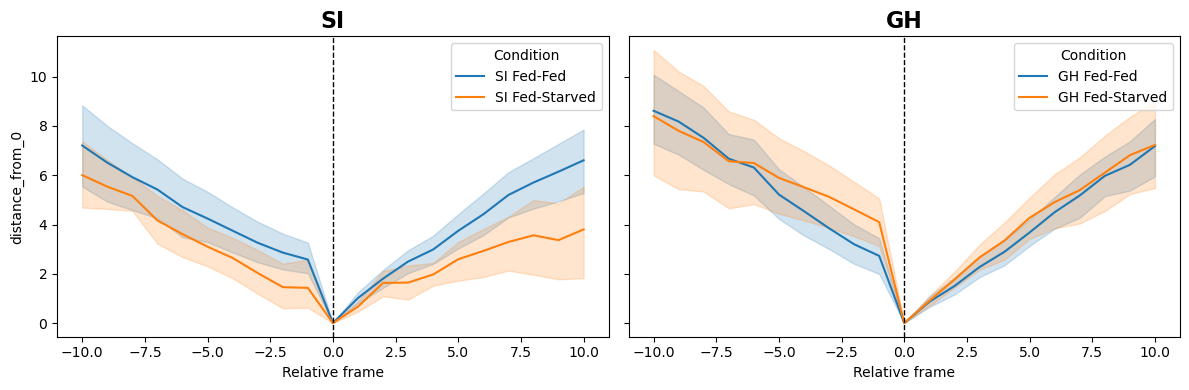

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12,4), sharey=True)

# ---------------- SI ----------------
sns.lineplot(
    data=si_first_interaction,
    x='rel_frame',
    y='distance_from_0',
    hue='Condition',
    errorbar=('ci', 95),
    ax=axes[0]
)

axes[0].axvline(0, color='black', linestyle='--', linewidth=1)
axes[0].set_title('SI', fontsize=16, fontweight='bold')
axes[0].set_xlabel('Relative frame')
axes[0].set_ylabel('distance_from_0')

# ---------------- GH ----------------
sns.lineplot(
    data=gh_first_interaction,
    x='rel_frame',
    y='distance_from_0',
    hue='Condition',
    errorbar=('ci', 95),
    ax=axes[1]
)

axes[1].axvline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_title('GH', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Relative frame')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

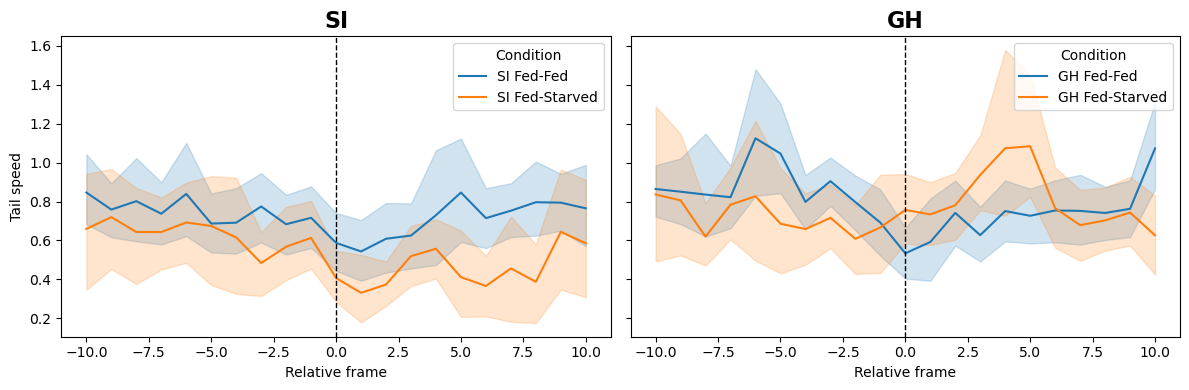

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12,4), sharey=True)

# ---------------- SI ----------------
sns.lineplot(
    data=si_first_interaction,
    x='rel_frame',
    y='speed_tail',
    hue='Condition',
    errorbar=('ci', 95),
    ax=axes[0]
)

axes[0].axvline(0, color='black', linestyle='--', linewidth=1)
axes[0].set_title('SI', fontsize=16, fontweight='bold')
axes[0].set_xlabel('Relative frame')
axes[0].set_ylabel('Tail speed')

# ---------------- GH ----------------
sns.lineplot(
    data=gh_first_interaction,
    x='rel_frame',
    y='speed_tail',
    hue='Condition',
    errorbar=('ci', 95),
    ax=axes[1]
)

axes[1].axvline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_title('GH', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Relative frame')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

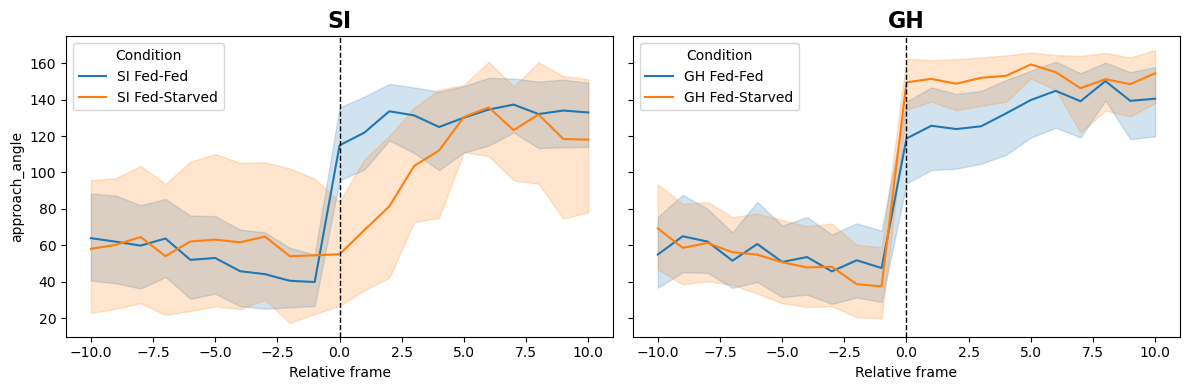

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12,4), sharey=True)

# ---------------- SI ----------------
sns.lineplot(
    data=si_first_interaction,
    x='rel_frame',
    y='approach_angle',
    hue='Condition',
    errorbar=('ci', 95),
    ax=axes[0]
)

axes[0].axvline(0, color='black', linestyle='--', linewidth=1)
axes[0].set_title('SI', fontsize=16, fontweight='bold')
axes[0].set_xlabel('Relative frame')
axes[0].set_ylabel('approach_angle')

# ---------------- GH ----------------
sns.lineplot(
    data=gh_first_interaction,
    x='rel_frame',
    y='approach_angle',
    hue='Condition',
    errorbar=('ci', 95),
    ax=axes[1]
)

axes[1].axvline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_title('GH', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Relative frame')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

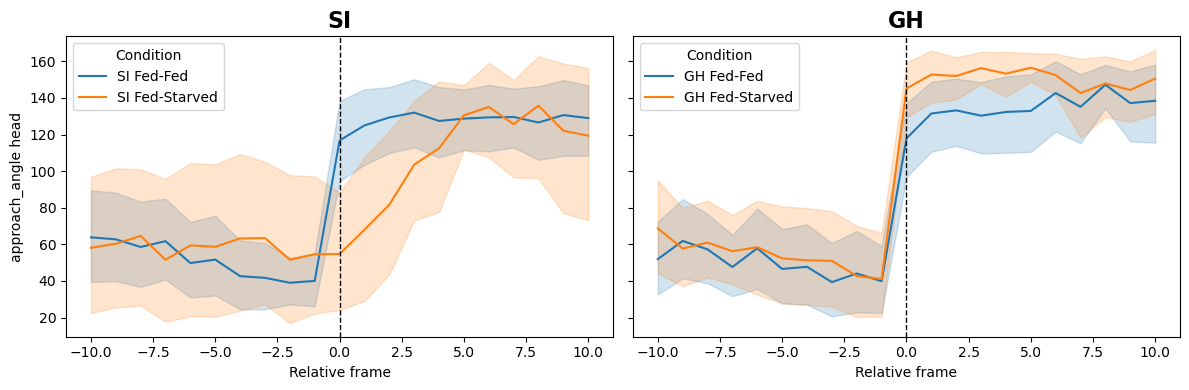

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12,4), sharey=True)

# ---------------- SI ----------------
sns.lineplot(
    data=si_first_interaction,
    x='rel_frame',
    y='approach_angle_head',
    hue='Condition',
    errorbar=('ci', 95),
    ax=axes[0]
)

axes[0].axvline(0, color='black', linestyle='--', linewidth=1)
axes[0].set_title('SI', fontsize=16, fontweight='bold')
axes[0].set_xlabel('Relative frame')
axes[0].set_ylabel('approach_angle head')

# ---------------- GH ----------------
sns.lineplot(
    data=gh_first_interaction,
    x='rel_frame',
    y='approach_angle_head',
    hue='Condition',
    errorbar=('ci', 95),
    ax=axes[1]
)

axes[1].axvline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_title('GH', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Relative frame')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

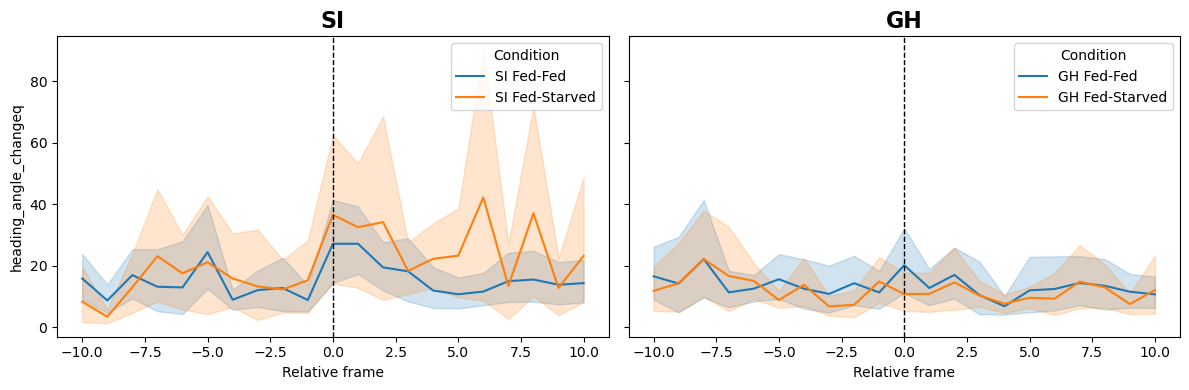

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12,4), sharey=True)

# ---------------- SI ----------------
sns.lineplot(
    data=si_first_interaction,
    x='rel_frame',
    y='heading_angle_change',
    hue='Condition',
    errorbar=('ci', 95),
    ax=axes[0]
)

axes[0].axvline(0, color='black', linestyle='--', linewidth=1)
axes[0].set_title('SI', fontsize=16, fontweight='bold')
axes[0].set_xlabel('Relative frame')
axes[0].set_ylabel('heading_angle_changeq')

# ---------------- GH ----------------
sns.lineplot(
    data=gh_first_interaction,
    x='rel_frame',
    y='heading_angle_change',
    hue='Condition',
    errorbar=('ci', 95),
    ax=axes[1]
)

axes[1].axvline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_title('GH', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Relative frame')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

# OTHER

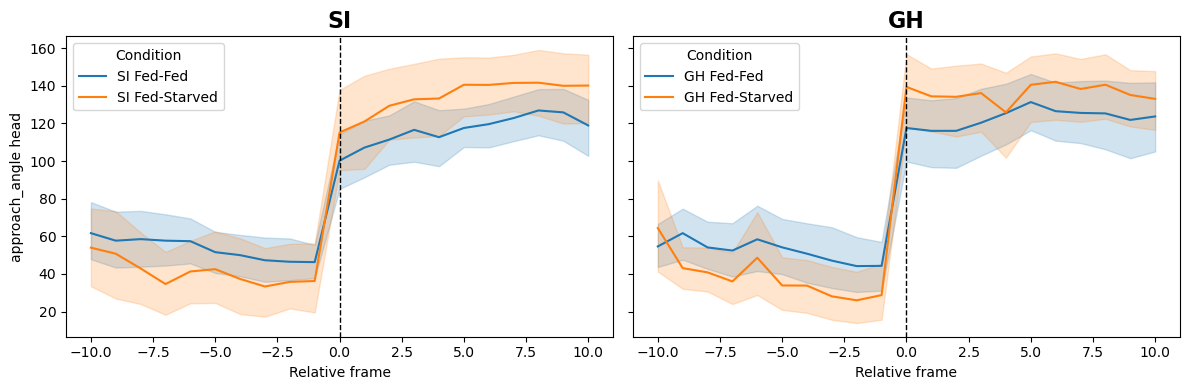

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12,4), sharey=True)

# ---------------- SI ----------------
sns.lineplot(
    data=si_other_interaction,
    x='rel_frame',
    y='approach_angle_head',
    hue='Condition',
    errorbar=('ci', 95),
    ax=axes[0]
)

axes[0].axvline(0, color='black', linestyle='--', linewidth=1)
axes[0].set_title('SI', fontsize=16, fontweight='bold')
axes[0].set_xlabel('Relative frame')
axes[0].set_ylabel('approach_angle head')

# ---------------- GH ----------------
sns.lineplot(
    data=gh_other_interaction,
    x='rel_frame',
    y='approach_angle_head',
    hue='Condition',
    errorbar=('ci', 95),
    ax=axes[1]
)

axes[1].axvline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_title('GH', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Relative frame')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

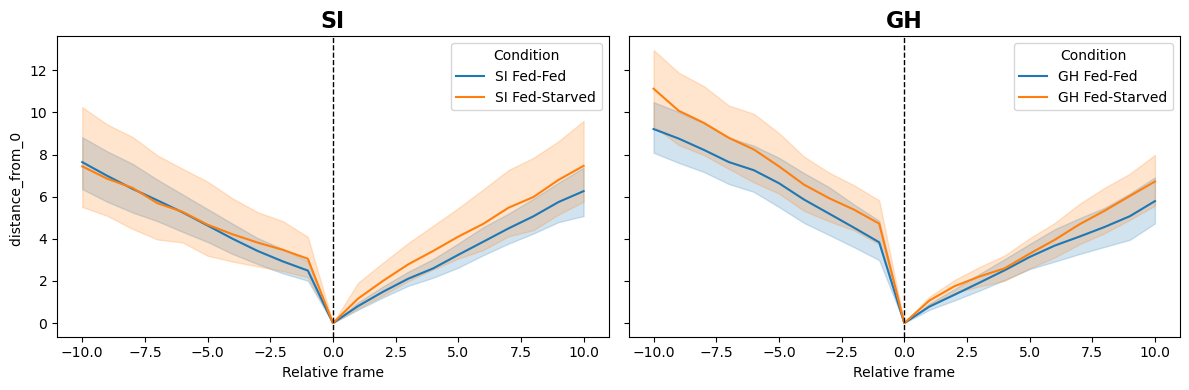

In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(12,4), sharey=True)

# ---------------- SI ----------------
sns.lineplot(
    data=si_other_interaction,
    x='rel_frame',
    y='distance_from_0',
    hue='Condition',
    errorbar=('ci', 95),
    ax=axes[0]
)

axes[0].axvline(0, color='black', linestyle='--', linewidth=1)
axes[0].set_title('SI', fontsize=16, fontweight='bold')
axes[0].set_xlabel('Relative frame')
axes[0].set_ylabel('distance_from_0 ')

# ---------------- GH ----------------
sns.lineplot(
    data=gh_other_interaction,
    x='rel_frame',
    y='distance_from_0',
    hue='Condition',
    errorbar=('ci', 95),
    ax=axes[1]
)

axes[1].axvline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_title('GH', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Relative frame')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

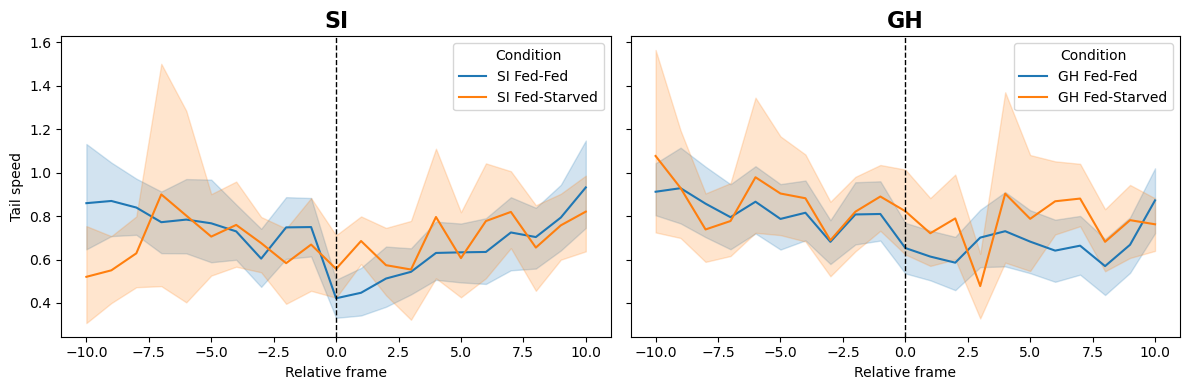

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12,4), sharey=True)

# ---------------- SI ----------------
sns.lineplot(
    data=si_other_interaction,
    x='rel_frame',
    y='speed_tail',
    hue='Condition',
    errorbar=('ci', 95),
    ax=axes[0]
)

axes[0].axvline(0, color='black', linestyle='--', linewidth=1)
axes[0].set_title('SI', fontsize=16, fontweight='bold')
axes[0].set_xlabel('Relative frame')
axes[0].set_ylabel('Tail speed')

# ---------------- GH ----------------
sns.lineplot(
    data=gh_other_interaction,
    x='rel_frame',
    y='speed_tail',
    hue='Condition',
    errorbar=('ci', 95),
    ax=axes[1]
)

axes[1].axvline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_title('GH', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Relative frame')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()